**Regulatory memory and growth-coupled inheritance shape nutrient-dependent flagella number variation in $\textit{Salmonella}$**

Authors: Arnab Barua$^{a,\dagger}$, Maria Giralt-Zuñiga$^{b,\dagger}$, Marc Erhardt$^{b,d}$ , Haralampos Hatzikirou$^{a,b}$

Affiliation: (a) Mathematics Department, Khalifa University, P.O.~Box 127788, Abu Dhabi, UAE

(b) Center for Information Services and High Performance Computing,
Technische Universität Dresden, Nöthnitzer Straße 46, 01062 Dresden, Germany

(c)Institute of Biology / Molecular Microbiology, Humboldt-Universität zu Berlin, Berlin, Germany

(d)Max Planck Unit for the Science of Pathogens, Berlin, Germany


## Shared model (single source of truth)

All mean-field trajectories below are produced by the functions defined in the next cell. The frozen relaxation rate is $\lambda=\mu_0-a\,k$ (WT: $k=k(\rho_\infty)=K_0+\Gamma\rho^{*2}$; mutant: $k=k_0=K_0$). No later cell redefines the model, so the analytical rate cannot drift out of sync between figures/tables. Run this cell first.

In [ ]:
# =====================================================================
#  SHARED MODEL  —  single source of truth
# ---------------------------------------------------------------------
#  Frozen-rate convention (used by EVERY cell below):
#       lambda = mu0 - a*k
#         WT  : k = k(rho_inf) = K0 + GAMMA * rho_star**2
#         Mut : k = k0         = K0
#  No other cell redefines the mean-field model; they all call the
#  functions defined here, so the analytical rate can never drift out
#  of sync across figures/tables again.
# =====================================================================
import os, numpy as np
from scipy.integrate import solve_ivp

# ---- output location + cache (shared by every cell) -----------------
OUT_DIR = os.environ.get("FLAG_OUT_DIR", "outputs")
os.makedirs(OUT_DIR, exist_ok=True)
CACHE   = os.path.join(OUT_DIR, "sim_cache_hybrid.pkl")

# ---- physical constants ---------------------------------------------
A_FIXED = 0.000265      # per-flagellum growth-cost coefficient  a
C_WT    = 100.0         # sensing coupling c  (only c*Gamma(rho) identifiable)
GAMMA   = C_WT / 2.0    # small-rho coefficient: k = k0 + GAMMA*rho**2
RHO_MAX = 0.99999

# ---- frozen relaxation rate  lambda = mu0 - a*k ---------------------
def lam_wt(mu0, K0, rho_star):
    """WT rate frozen at the steady-state target k(rho_inf)=K0+GAMMA*rho_star**2."""
    return max(float(mu0) - A_FIXED * (K0 + GAMMA * rho_star**2), 1e-6)

def lam_mut(mu0, K0):
    """Mutant rate frozen at the baseline target k0 = K0."""
    return max(float(mu0) - A_FIXED * K0, 1e-6)

def _A_coeff(lam, alpha, B):
    if abs(lam - alpha) < 1e-8 * max(lam, alpha, 1e-10):
        return None
    return lam * B / (lam - alpha)

def _Gamma_full(rho):
    rho = np.clip(float(rho), 0.0, 0.9999)
    return 1.0 / np.sqrt(1.0 - rho**2) - 1.0

# ---- latent correlation rho(t) --------------------------------------
def rho_mut(t, rho0_mut, tau_rho):
    return rho0_mut * np.exp(-np.asarray(t, dtype=float) / tau_rho)

def rho_wt(t, rho0_wt, rho_star, tau_rho):
    t = np.asarray(t, dtype=float)
    return rho_star + (rho0_wt - rho_star) * np.exp(-t / tau_rho)

# ---- analytical (frozen-rate) mean-field trajectories ---------------
def X_analytical_mut(t, K0, X0, rho0_mut, tau_rho, mu0):
    t     = np.asarray(t, dtype=float)
    lam   = lam_mut(mu0, K0)                       # mu0 - a*k0
    alpha = 2.0 / tau_rho
    B     = GAMMA * rho0_mut**2
    A     = _A_coeff(lam, alpha, B)
    if A is None:
        return K0 + (X0 - K0) * np.exp(-lam*t) + lam*B*t*np.exp(-lam*t)
    return K0 + (X0 - K0 - A)*np.exp(-lam*t) + A*np.exp(-alpha*t)

def X_analytical_wt(t, K0, X0, rho0_wt, rho_star, tau_rho, mu0):
    t      = np.asarray(t, dtype=float)
    k_inf  = K0 + GAMMA * rho_star**2
    lam    = lam_wt(mu0, K0, rho_star)             # mu0 - a*k(rho_inf)
    delta  = rho0_wt - rho_star
    B1     = 2.0 * GAMMA * rho_star * delta
    B2     = GAMMA * delta**2
    a1     = 1.0 / tau_rho
    a2     = 2.0 / tau_rho
    A1c     = _A_coeff(lam, a1, B1)
    A1_term = (lam*B1*t*np.exp(-lam*t)) if A1c is None else (A1c*np.exp(-a1*t))
    A1c     = 0.0 if A1c is None else A1c
    A2c     = _A_coeff(lam, a2, B2)
    A2_term = (lam*B2*t*np.exp(-lam*t)) if A2c is None else (A2c*np.exp(-a2*t))
    A2c     = 0.0 if A2c is None else A2c
    return k_inf + A1_term + A2_term + (X0 - k_inf - A1c - A2c)*np.exp(-lam*t)

# ---- full nonlinear ODE (RK45 reference; exact (mu0 - a X) rate) -----
def ode_wt_full(t, y, rho_star, tau_rho, K0, mu0):
    X, rho = y
    rho = np.clip(rho, 0.0, RHO_MAX - 1e-6)
    k   = K0 + C_WT * _Gamma_full(rho)
    return [(mu0 - A_FIXED*X)*(k - X), rho_star/tau_rho - rho/tau_rho]

def ode_mut_full(t, y, tau_rho, K0, mu0):
    X, rho = y
    rho = np.clip(rho, 0.0, 0.9999)
    k   = K0 + C_WT * _Gamma_full(rho)
    return [(mu0 - A_FIXED*X)*(k - X), -rho/tau_rho]

def integrate_full(ode_func, y0, t_eval, **kwargs):
    t_eval = np.asarray(t_eval, dtype=float)
    sol = solve_ivp(lambda t, y: ode_func(t, y, **kwargs),
                    (0.0, float(t_eval.max())), y0,
                    t_eval=t_eval, method="RK45", rtol=1e-8, atol=1e-10)
    if not sol.success:
        raise RuntimeError(f"ODE solver failed: {sol.message}")
    return sol.y

print("[shared model] lambda = mu0 - a*k   (WT: k(rho_inf);  mut: k0).   OUT_DIR =", OUT_DIR)


[shared model] lambda = mu0 - a*k   (WT: k(rho_inf);  mut: k0).   OUT_DIR = outputs


*Distribution Flagella from different nutrient setups (i.e., 0.2%, 0.4%, 0.5% and 1%) and evolution flagella at different time points (i.e., 60 min, 90 min, 120 min, 150 min and 180 min) with three replicates R1, R2 and R3*

**Fig 3. **Plot of the raw distribution of flagella at different time points and for different nutrient concentration after averaging 3 replicates as  a row format plot for both WT and Mutant DrflP strain.

WT integrity (expected total = 300):
  WT R1 0.20% t=120: sum=301 (+1)
  WT R1 0.20% t=150: sum=304 (+4)
  WT R1 1% t=60: sum=299 (-1)
  WT R1 1% t=90: sum=301 (+1)
  WT R1 1% t=120: sum=301 (+1)
  WT R1 1% t=150: sum=301 (+1)
  WT R2 0.50% t=240: sum=301 (+1)
Mutant totals (informational; flag if far from ~300):
  mut R2 0.2 t=60: sum=419  <-- OUTLIER, check source



<>:104: SyntaxWarning: invalid escape sequence '\D'
<>:104: SyntaxWarning: invalid escape sequence '\D'
<>:104: SyntaxWarning: invalid escape sequence '\D'
<>:104: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1005/1649780493.py:104: SyntaxWarning: invalid escape sequence '\D'
  for col, (conc, title) in enumerate(zip(mut_concs, ['$\Delta$rflP 0.2% conc.','$\Delta$rflP 1% conc.'])):
/tmp/ipykernel_1005/1649780493.py:104: SyntaxWarning: invalid escape sequence '\D'
  for col, (conc, title) in enumerate(zip(mut_concs, ['$\Delta$rflP 0.2% conc.','$\Delta$rflP 1% conc.'])):


Done.


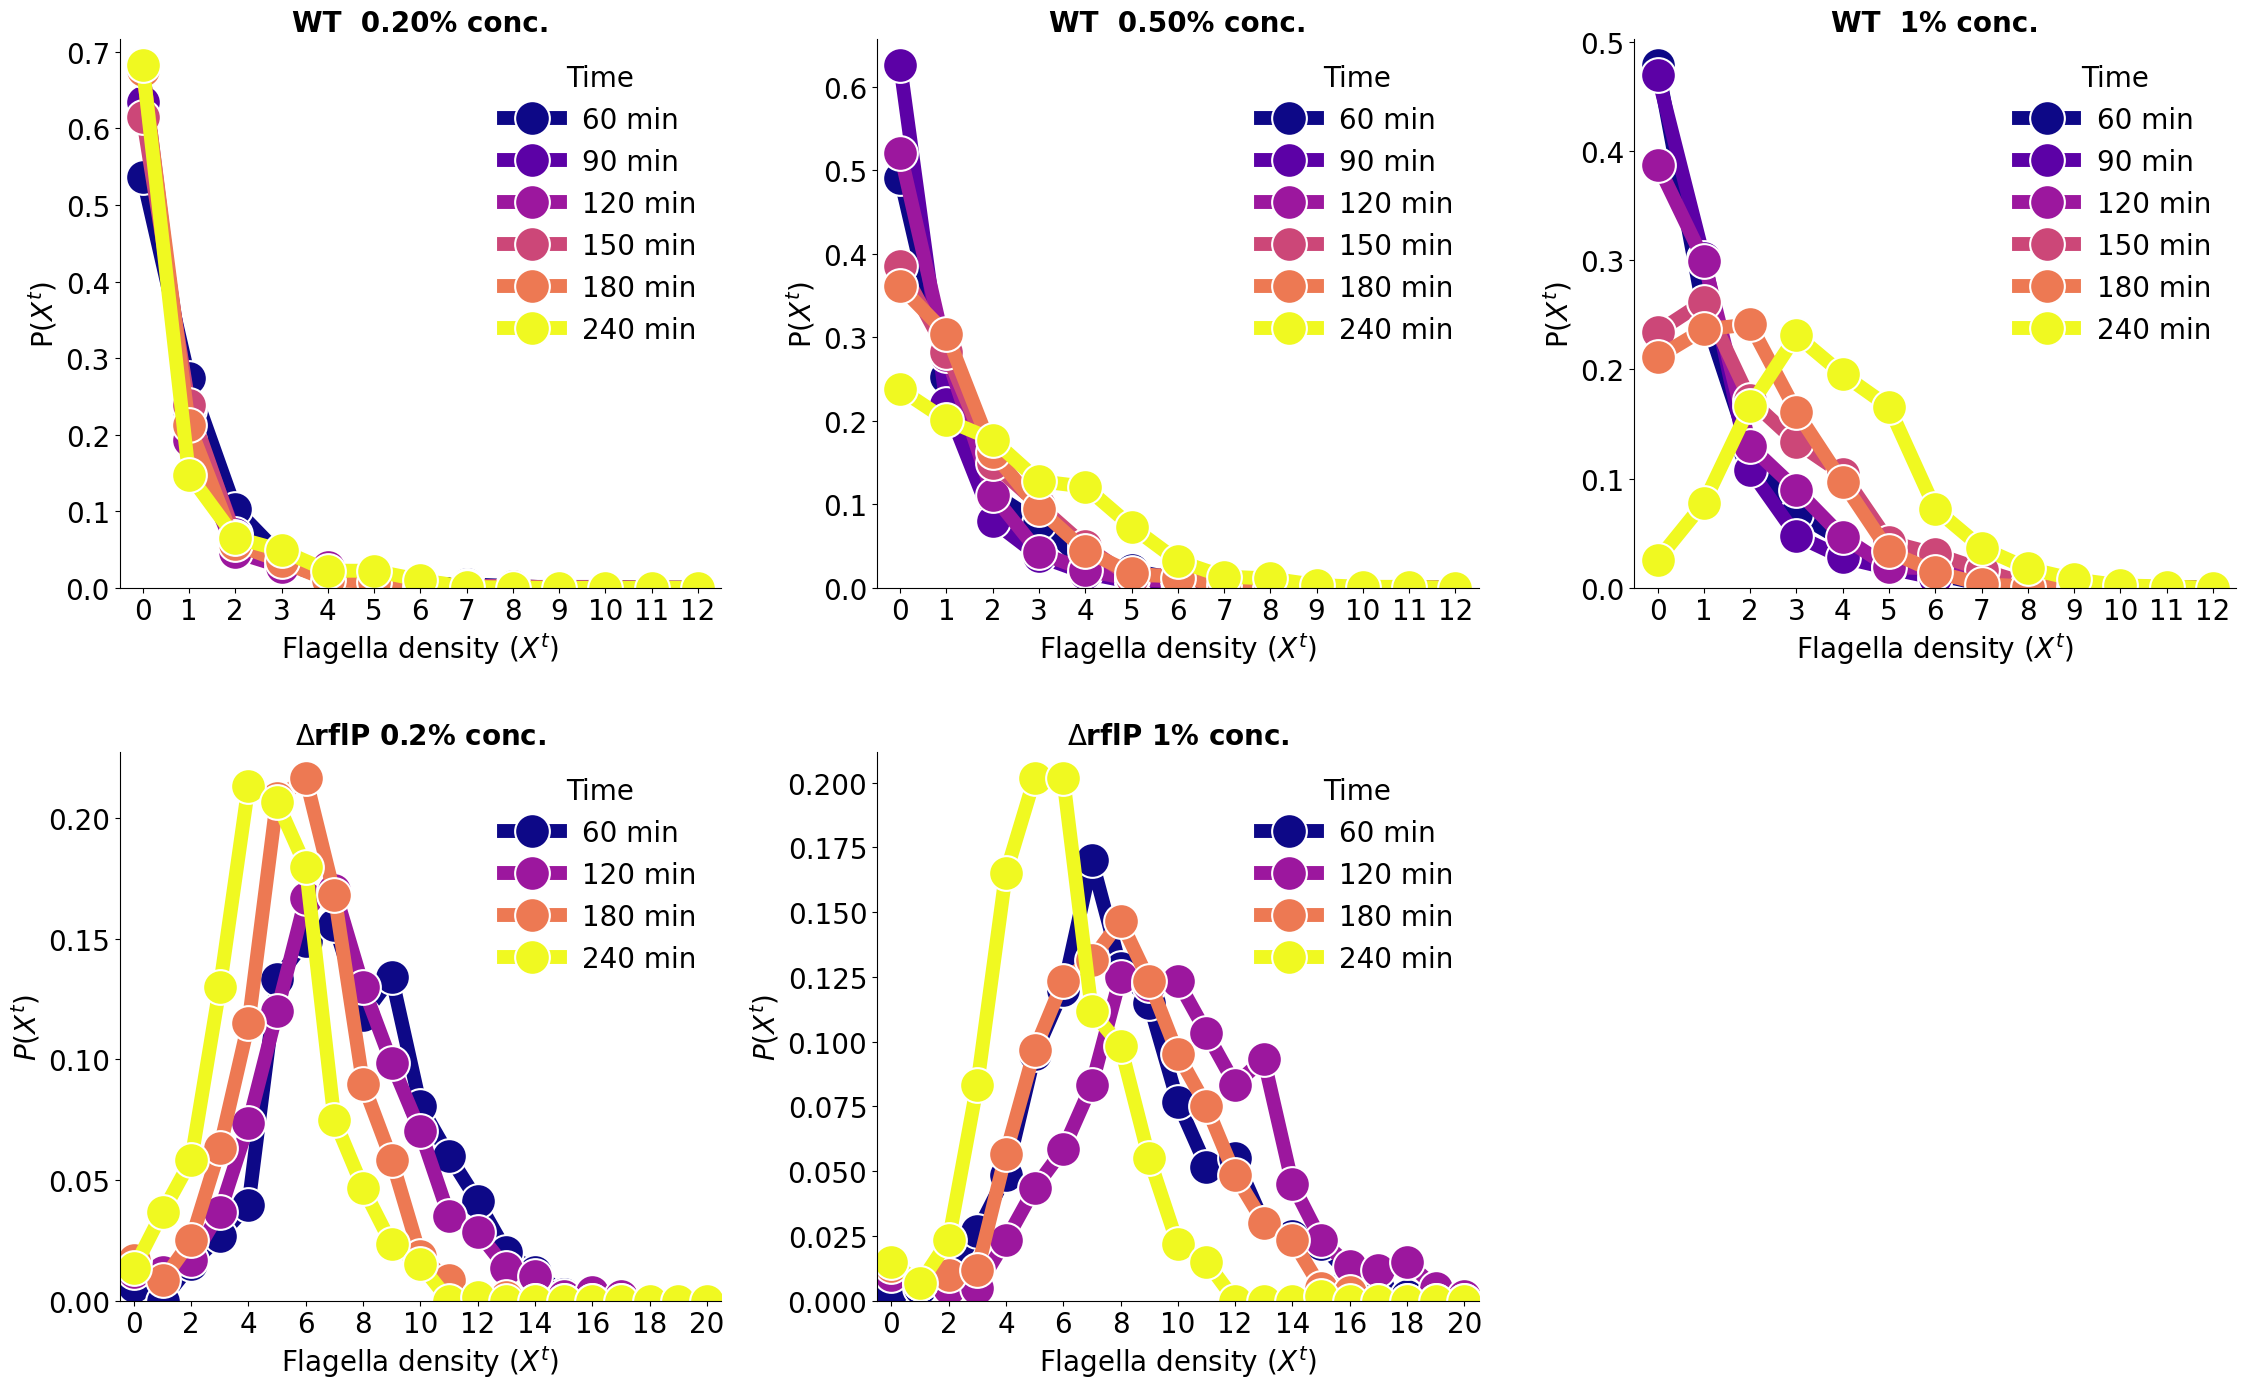

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

### Experimental dataset of flagella density over different time points and nutrient concentration ###
flagella_data = {
    'R1': {
        '0.20%': {60:{0:147,1:74,2:45,3:15,4:10,5:4,6:3,7:1,8:1},90:{0:166,1:66,2:30,3:18,4:6,5:9,6:2,7:1,8:1,10:1},120:{0:196,1:51,2:14,3:12,4:14,5:8,6:2,7:1,8:1,9:1,10:1},150:{0:141,1:85,2:28,3:24,4:11,5:7,6:4,7:2,8:2},180:{0:203,1:52,2:28,3:12,4:1,5:3,7:1},240:{0:199,1:47,2:21,3:15,4:6,5:9,6:2,7:1}},
        '0.50%': {60:{0:174,1:66,2:31,3:19,4:4,5:4,6:2},90:{0:120,1:93,2:40,3:21,4:12,5:3,6:5,7:2,8:3,10:1},120:{0:154,1:78,2:37,3:11,4:7,5:4,6:5,7:2,8:1,11:1},150:{0:109,1:82,2:47,3:34,4:13,5:4,6:8,7:2,8:1},180:{0:91,1:91,2:63,3:27,4:18,5:3,6:5,7:2},240:{0:86,1:50,2:49,3:49,4:32,5:20,6:11,7:2,8:1}},
        '1%':    {60:{0:144,1:70,2:36,3:23,4:17,5:4,6:4,7:1},90:{0:89,1:99,2:40,3:22,4:14,5:13,6:8,7:9,8:2,9:2,10:2,12:1},120:{0:56,1:91,2:62,3:44,4:25,5:8,6:11,7:3,8:1},150:{0:7,1:48,2:61,3:70,4:54,5:25,6:20,7:12,8:3,9:1},180:{0:2,1:51,2:100,3:83,4:42,5:17,6:3,7:2},240:{0:16,1:15,2:49,3:64,4:69,5:55,6:15,7:9,8:7,9:1}},  # 240 FIXED (was mutant data)
    },
    'R2': {
        '0.20%': {60:{0:136,1:87,2:38,3:17,4:6,5:10,6:2,7:3,8:1},90:{0:212,1:65,2:13,3:7,4:3},120:{0:192,1:67,2:16,3:10,4:8,5:4,6:2,7:1},150:{0:213,1:60,2:15,3:6,4:4,5:2},180:{0:222,1:49,2:9,3:11,4:5,5:3,6:1},240:{0:224,1:39,2:17,3:10,4:6,5:3,6:1}},
        '0.50%': {60:{0:141,1:80,2:32,3:26,4:9,5:7,6:4,7:1},90:{0:218,1:55,2:16,3:8,4:1,5:2},120:{0:160,1:85,2:32,3:14,4:8,5:1},150:{0:114,1:81,2:47,3:28,4:16,5:6,6:6,7:2},180:{0:117,1:93,2:41,3:23,4:16,5:6,6:3,7:1},240:{0:80,1:87,2:76,3:26,4:25,5:6,8:1}},  # 240 sum=301 (real)
        '1%':    {60:{0:162,1:62,2:36,3:17,4:12,5:5,6:5,7:1},90:{0:173,1:75,2:29,3:15,4:7,5:1},120:{0:144,1:78,2:34,3:23,4:11,5:3,6:2,7:4,8:1},150:{0:88,1:80,2:51,3:33,4:30,5:9,6:7,7:2},180:{0:91,1:68,2:53,3:34,4:32,5:12,6:7,7:1,8:1,9:1},240:{0:3,1:47,2:69,3:91,4:41,5:33,6:11,7:3,8:1,11:1}},
    },
    'R3': {
        '0.20%': {60:{0:200,1:85,2:10,3:5},90:{0:193,1:78,2:20,3:5,4:2,5:1,6:1},120:{0:225,1:56,2:12,3:3,4:2,5:1,6:1},150:{0:201,1:71,2:17,3:5,4:2,5:3,6:1},180:{0:184,1:90,2:14,3:8,4:3,5:1},240:{0:191,1:47,2:21,3:19,4:8,5:8,6:6}},
        '0.50%': {60:{0:127,1:81,2:39,3:25,4:11,5:8,6:3,7:4,8:2},90:{0:225,1:50,2:16,3:5,4:3,5:1},120:{0:155,1:88,2:31,3:13,4:4,5:4,6:2,7:1,8:1,9:1},150:{0:124,1:91,2:40,3:27,4:16,5:1,6:1},180:{0:117,1:90,2:42,3:35,4:6,5:7,6:3},240:{0:48,1:44,2:35,3:40,4:52,5:40,6:18,7:10,8:8,9:3,10:1,11:1}},
        '1%':    {60:{0:124,1:95,2:40,3:21,4:10,5:7,6:2,7:1},90:{0:161,1:98,2:28,3:6,4:4,5:2,7:1},120:{0:149,1:101,2:21,3:14,4:6,5:6,6:3},150:{0:116,1:108,2:43,3:17,4:10,5:4,6:1,7:1},180:{0:97,1:94,2:64,3:28,4:13,5:1,6:3},240:{0:4,1:8,2:32,3:53,4:66,5:61,6:39,7:21,8:8,9:6,10:2}},
    },
}

mutant_flagella_data = {
    'R1': {  # VERIFIED DrflP_WT_replicate1.xlsx
        '0.2': {60:{2:4,3:6,4:11,5:40,6:38,7:44,8:33,9:44,10:22,11:21,12:19,13:10,14:5,15:1,16:1,17:1},120:{0:1,1:1,2:4,3:11,4:21,5:25,6:49,7:48,8:38,9:32,10:26,11:15,12:13,13:8,14:4,15:1,16:1,17:1},180:{0:8,1:4,2:12,3:27,4:47,5:72,6:54,7:44,8:14,9:14,10:2,11:2},240:{0:3,1:14,2:18,3:35,4:55,5:62,6:51,7:33,8:15,9:7,10:6,12:1}},
        '1':   {60:{1:1,2:1,3:6,4:7,5:23,6:30,7:48,8:37,9:35,10:24,11:16,12:24,13:13,14:10,15:13,16:6,17:3,18:1,19:1,20:1},120:{0:1,1:1,3:1,4:5,5:9,6:17,7:24,8:33,9:29,10:35,11:27,12:28,13:39,14:14,15:11,16:6,17:7,18:9,19:3,20:1},180:{0:3,1:1,2:3,3:5,4:25,5:41,6:56,7:53,8:46,9:30,10:18,11:10,12:7,13:1,14:1},240:{0:2,1:2,2:10,3:32,4:63,5:59,6:54,7:23,8:25,9:18,10:6,11:5,15:1}},
    },
    'R2': {  # VERIFIED DrflP_replicate2.xlsx
        '0.2': {60:{0:5,2:7,3:14,4:18,5:56,6:72,7:69,8:53,9:51,10:37,11:21,12:8,13:3,14:3,15:1,16:1},120:{0:6,1:6,2:6,3:11,4:23,5:47,6:51,7:54,8:40,9:27,10:16,11:6,12:4,14:2,16:1},180:{0:2,1:1,2:3,3:11,4:22,5:53,6:76,7:57,8:40,9:21,10:9,11:3,12:1,13:1},240:{0:5,1:8,2:17,3:43,4:73,5:62,6:57,7:12,8:13,9:7,10:3}},
        '1':   {60:{0:2,1:2,2:4,3:10,4:22,5:34,6:42,7:54,8:40,9:34,10:22,11:15,12:9,13:5,14:5},120:{0:5,1:3,2:3,3:2,4:9,5:17,6:18,7:26,8:42,9:44,10:39,11:35,12:22,13:17,14:13,15:3,16:2},180:{0:5,1:3,2:3,3:2,4:9,5:17,6:18,7:26,8:42,9:44,10:39,11:35,12:22,13:17,14:13,15:3,16:2},240:{0:7,1:2,2:4,3:18,4:36,5:62,6:67,7:44,8:34,9:15,10:7,11:4}},
    },

}

# ── data integrity check (counts should total 300) ─────────────────────────────
def integrity_check():
    # WT counts are standardised to 300 cells; flag any deviation.
    print("WT integrity (expected total = 300):")
    bad = False
    for rep in flagella_data:
        for conc, td in flagella_data[rep].items():
            for t, d in td.items():
                s = sum(d.values())
                if s != 300:
                    bad = True
                    print(f"  WT {rep} {conc} t={t}: sum={s} ({s-300:+d})")
    if not bad: print("  all WT distributions sum to 300.")
    # Mutant counts are NOT strictly 300; report totals and flag large outliers.
    print("Mutant totals (informational; flag if far from ~300):")
    for rep in mutant_flagella_data:
        for conc, td in mutant_flagella_data[rep].items():
            for t, d in td.items():
                s = sum(d.values())
                if abs(s - 300) > 10:
                    print(f"  mut {rep} {conc} t={t}: sum={s}  <-- OUTLIER, check source")
    print()
integrity_check()

# ── helpers ───────────────────────────────────────────────────────────────────
def to_fractions(count_dict, max_f):
    arr = np.zeros(max_f + 1); total = sum(count_dict.values())
    if total == 0: return arr
    for k, v in count_dict.items():
        if k <= max_f: arr[k] = v / total
    return arr

def avg_over(data, conc, times, max_f):
    reps = list(data.keys()); avg = {}
    for t in times:
        arrays = [to_fractions(data[r][conc][t], max_f)
                  for r in reps if conc in data[r] and t in data[r][conc]]
        if arrays: avg[t] = np.mean(arrays, axis=0)
    return avg

avg_wt  = lambda conc, times, max_f=12: avg_over(flagella_data, conc, times, max_f)
avg_mut = lambda conc, times, max_f:    avg_over(mutant_flagella_data, conc, times, max_f)

# ── style params ──────────────────────────────────────────────────────────────
FS, LFS, TP, LW, MS = 20, 20, 20, 10, 25
wt_concs  = ['0.20%', '0.50%', '1%']; wt_times = [60, 90, 120, 150, 180, 240]
mut_concs = ['0.2', '1'];             mut_times = [60, 120, 180, 240]
MAX_WT, MAX_MUT = 12, 20
cmap = plt.colormaps['plasma']
norm_wt  = mcolors.Normalize(vmin=min(wt_times),  vmax=max(wt_times))
norm_mut = mcolors.Normalize(vmin=min(mut_times), vmax=max(mut_times))

fig, axes = plt.subplots(2, 3, figsize=(24, 14)); fig.patch.set_facecolor('white')

for col, (conc, title) in enumerate(zip(wt_concs, ['WT  0.20% conc.','WT  0.50% conc.','WT  1% conc.'])):
    ax = axes[0, col]; ax.set_facecolor('white')
    avg = avg_wt(conc, wt_times, MAX_WT); x = np.arange(MAX_WT + 1)
    for t in wt_times:
        if t not in avg: continue
        c = cmap(norm_wt(t))
        ax.plot(x, avg[t], color=c, linewidth=LW, marker='o', markersize=MS,
                markerfacecolor=c, markeredgecolor='white', markeredgewidth=1.5, label=f'{t} min')
    ax.set_xlim(-0.5, MAX_WT+0.5); ax.set_ylim(0, None); ax.set_xticks(x)
    ax.set_xlabel('Flagella density ($X^t$)', fontsize=FS); ax.set_ylabel('P($X^t$)', fontsize=FS)
    ax.set_title(title, fontsize=FS, fontweight='bold'); ax.tick_params(axis='both', labelsize=TP)
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=LFS, frameon=False, title='Time', title_fontsize=LFS)

for col, (conc, title) in enumerate(zip(mut_concs, ['$\Delta$rflP 0.2% conc.','$\Delta$rflP 1% conc.'])):
    ax = axes[1, col]; ax.set_facecolor('white')
    x = np.arange(MAX_MUT + 1); avg = avg_mut(conc, mut_times, MAX_MUT)
    for t in mut_times:
        if t not in avg: continue
        c = cmap(norm_mut(t))
        ax.plot(x, avg[t], color=c, linewidth=LW, marker='o', markersize=MS,
                markerfacecolor=c, markeredgecolor='white', markeredgewidth=1.5, label=f'{t} min')
    ax.set_xlim(-0.5, MAX_MUT+0.5); ax.set_ylim(0, None); ax.set_xticks(np.arange(0, MAX_MUT+1, 2))
    ax.set_xlabel('Flagella density ($X^t$)', fontsize=FS); ax.set_ylabel('$P(X^t)$', fontsize=FS)
    ax.set_title(title, fontsize=FS, fontweight='bold'); ax.tick_params(axis='both', labelsize=TP)
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=LFS, frameon=False, title='Time', title_fontsize=LFS)

axes[1, 2].set_visible(False)
plt.tight_layout(rect=[0, 0, 0.94, 1], h_pad=4, w_pad=3)
plt.savefig(OUT_DIR+'/flagella_distribution.png', dpi=180, bbox_inches='tight', facecolor='white')
print("Done.")

 **Fig.4:** Bacteria growth is measured by OD600 at different concentrations and at different time points after averaging over 3 replicates ( please see S.I. for details )for both WT and DrflP mutant

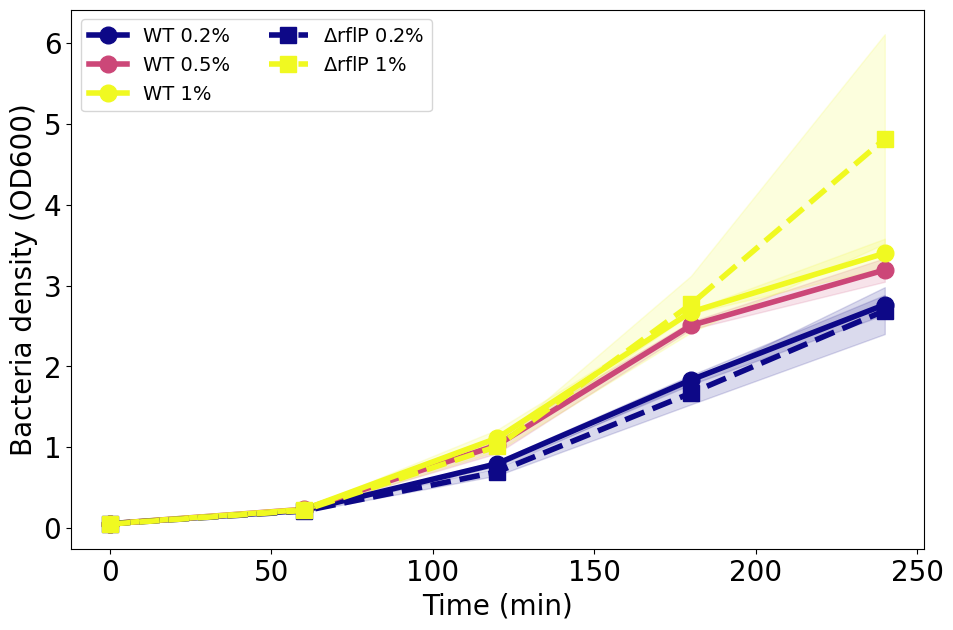

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# GROWTH (OD600) - all VERIFIED against Dataset1/2/3_WT_DrflP_240min.xlsx
#   Each dataset is one experimental run measuring WT (0.2/0.5/1%) and
#   DrflP (0.2/1%) together, 0..240 min.  -> 3 replicates, both strains, to 240.
#   NOTE: these datasets do NOT include the 0.4% WT condition, so 0.4% is not
#   plotted here (it existed only in the 0..180 flagella-timecourse OD sheets).
#   wt_rep1..3 <- Dataset3/Dataset2/Dataset1 WT ; mut_rep1..3 <- Dataset1/2/3 DrflP.
# =============================================================================

# ── WT data (3 replicates, 3 concentrations, 0..240) ───────────────────────────
wt_rep1 = {'0.2%': [0.055, 0.202, 0.75, 1.76, 2.6],  '0.5%': [0.054, 0.217, 0.96, 2.44, 3.09], '1%': [0.054, 0.218, 1.04, 2.67, 3.38]}  # Dataset3
wt_rep2 = {'0.2%': [0.052, 0.225, 0.81, 1.9,  2.8],  '0.5%': [0.052, 0.227, 0.95, 2.53, 3.09], '1%': [0.051, 0.229, 1.04, 2.7,  3.19]}  # Dataset2
wt_rep3 = {'0.2%': [0.054, 0.228, 0.83, 1.84, 2.89], '0.5%': [0.054, 0.248, 1.17, 2.55, 3.4],  '1%': [0.052, 0.238, 1.26, 2.65, 3.63]}  # Dataset1
wt_reps  = [wt_rep1, wt_rep2, wt_rep3]
wt_concs = ['0.2%', '0.5%', '1%']

# ── DrflP mutant data (2 replicates, 2 concentrations, 0..240) ─────────────────
mut_rep1 = {'0.2%': [0.054, 0.22,  0.74, 1.53, 2.4],  '1%': [0.051, 0.231, 1.07, 2.42, 3.52]}  # Dataset1
mut_rep2 = {'0.2%': [0.05,  0.199, 0.65, 1.81, 2.98], '1%': [0.047, 0.203, 0.95, 3.12, 6.11]}  # Dataset2

mut_reps  = [mut_rep1, mut_rep2]
mut_concs = ['0.2%', '1%']

times = np.array([0, 60, 120, 180, 240])   # shared time axis for both strains now

def mean_std(reps, conc):
    data = np.array([r[conc] for r in reps])
    return data.mean(axis=0), data.std(axis=0)

# ── style: colour = concentration, line style = strain ─────────────────────────
plasma = plt.get_cmap('plasma')
conc_color   = {c: plasma(v) for c, v in zip(wt_concs, np.linspace(0, 1, len(wt_concs)))}
strain_style = {'WT': dict(linestyle='-', marker='o'), 'DrflP': dict(linestyle='--', marker='s')}

fig, ax = plt.subplots(figsize=(11, 7))

for conc in wt_concs:                       # WT
    m, s = mean_std(wt_reps, conc)
    ax.plot(times, m, color=conc_color[conc], lw=4, markersize=12,
            label=f'WT {conc}', **strain_style['WT'])
    ax.fill_between(times, m - s, m + s, color=conc_color[conc], alpha=0.15)

for conc in mut_concs:                      # DrflP (matching concentrations)
    m, s = mean_std(mut_reps, conc)
    ax.plot(times, m, color=conc_color[conc], lw=4, markersize=12,
            label=f'$\\Delta$rflP {conc}', **strain_style['DrflP'])
    ax.fill_between(times, m - s, m + s, color=conc_color[conc], alpha=0.15)

ax.set_xlabel('Time (min)', fontsize=20)
ax.set_ylabel('Bacteria density (OD600)', fontsize=20)
ax.tick_params(labelsize=20)
ax.legend(fontsize=14, ncol=2)
plt.savefig(OUT_DIR+'/growth_WT_vs_DrflP.png',
            format='png', bbox_inches='tight')
plt.show()

Fitting Mean-field equation of flagella density for both WT and DrflP mutants. Furthermore the parameter estimation over different concnetration of nutrients are estimated here and 0.4% were fitted


In [ ]:
"""
run_simulations.py (HYBRID: Analytical + Numerical, Reduced Iterations)
=========================================================================

rho dynamics
------------
  Mutant:  rho(t)  = rho0_mut * exp(-t / tau_rho)
  WT:      rho(t)  = rho_star + (rho0_wt - rho_star)*exp(-t / tau_rho)

Shared parameters
-----------------
  tau_rho   — shared rho decay timescale (ALL strains, ALL concentrations)
  rho0_wt   — shared overnight rho, ALL WT concentrations
  rho0_mut  — shared overnight rho, ALL Mutant concentrations
  X0_wt     — shared initial flagella count, ALL WT concentrations
  X0_mut    — shared initial flagella count, ALL Mutant concentrations

Outer (5-D, warm starts + basin-hopping):
  (rho0_wt, rho0_mut, tau_rho, X0_wt, X0_mut)  — 5 params

Inner WT   (2-D NM, per conc):   (rho_star, K0)
Inner Mut  (1-D NM, per conc):   (K0)

HYBRID MODE:
  - Fits both analytical AND numerical solutions
  - Reports MSE for both
  - Uses reduced maxiter/maxfev for faster iteration

MUTANT DATA:
  - Mutant flagella-count distributions are now stored per-replicate (R1, R2),
    mirroring the WT data structure, and averaged across replicates the same
    way WT statistics are computed (mean-of-replicate-means).
"""

import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize  import minimize, basinhopping
import os, pickle


N_STARTS_INNER = 10       # Reduced from 20
N_BH_STEPS     = 2        # Reduced from 3
N_WARM_STARTS  = 5        # Keep at 5
RNG_SEED       = 42

# ─────────────────────────────── CONSTANTS ───────────────────────────────────

T_WT    = np.array([60, 90, 120, 150, 180, 240], dtype=float)
T_WT040 = np.array([60, 90, 120, 150, 180],       dtype=float)
T_MUT   = np.array([60, 120, 180, 240],            dtype=float)
T_DENSE = np.linspace(0, 260, 800)

# ─────────────────────────────── RAW DATA ────────────────────────────────────
flagella_data = {
    'R1': {
        '0.20%': {60:{0:147,1:74,2:45,3:15,4:10,5:4,6:3,7:1,8:1},90:{0:166,1:66,2:30,3:18,4:6,5:9,6:2,7:1,8:1,10:1},120:{0:196,1:51,2:14,3:12,4:14,5:8,6:2,7:1,8:1,9:1,10:1},150:{0:141,1:85,2:28,3:24,4:11,5:7,6:4,7:2,8:2},180:{0:203,1:52,2:28,3:12,4:1,5:3,7:1},240:{0:199,1:47,2:21,3:15,4:6,5:9,6:2,7:1}},
        '0.50%': {60:{0:174,1:66,2:31,3:19,4:4,5:4,6:2},90:{0:120,1:93,2:40,3:21,4:12,5:3,6:5,7:2,8:3,10:1},120:{0:154,1:78,2:37,3:11,4:7,5:4,6:5,7:2,8:1,11:1},150:{0:109,1:82,2:47,3:34,4:13,5:4,6:8,7:2,8:1},180:{0:91,1:91,2:63,3:27,4:18,5:3,6:5,7:2},240:{0:86,1:50,2:49,3:49,4:32,5:20,6:11,7:2,8:1}},
        '1%':    {60:{0:144,1:70,2:36,3:23,4:17,5:4,6:4,7:1},90:{0:89,1:99,2:40,3:22,4:14,5:13,6:8,7:9,8:2,9:2,10:2,12:1},120:{0:56,1:91,2:62,3:44,4:25,5:8,6:11,7:3,8:1},150:{0:7,1:48,2:61,3:70,4:54,5:25,6:20,7:12,8:3,9:1},180:{0:2,1:51,2:100,3:83,4:42,5:17,6:3,7:2},240:{0:16,1:15,2:49,3:64,4:69,5:55,6:15,7:9,8:7,9:1}},  # 240 FIXED (was mutant data)
    },
    'R2': {
        '0.20%': {60:{0:136,1:87,2:38,3:17,4:6,5:10,6:2,7:3,8:1},90:{0:212,1:65,2:13,3:7,4:3},120:{0:192,1:67,2:16,3:10,4:8,5:4,6:2,7:1},150:{0:213,1:60,2:15,3:6,4:4,5:2},180:{0:222,1:49,2:9,3:11,4:5,5:3,6:1},240:{0:224,1:39,2:17,3:10,4:6,5:3,6:1}},
        '0.50%': {60:{0:141,1:80,2:32,3:26,4:9,5:7,6:4,7:1},90:{0:218,1:55,2:16,3:8,4:1,5:2},120:{0:160,1:85,2:32,3:14,4:8,5:1},150:{0:114,1:81,2:47,3:28,4:16,5:6,6:6,7:2},180:{0:117,1:93,2:41,3:23,4:16,5:6,6:3,7:1},240:{0:80,1:87,2:76,3:26,4:25,5:6,8:1}},  # 240 sum=301 (real)
        '1%':    {60:{0:162,1:62,2:36,3:17,4:12,5:5,6:5,7:1},90:{0:173,1:75,2:29,3:15,4:7,5:1},120:{0:144,1:78,2:34,3:23,4:11,5:3,6:2,7:4,8:1},150:{0:88,1:80,2:51,3:33,4:30,5:9,6:7,7:2},180:{0:91,1:68,2:53,3:34,4:32,5:12,6:7,7:1,8:1,9:1},240:{0:3,1:47,2:69,3:91,4:41,5:33,6:11,7:3,8:1,11:1}},
    },
    'R3': {
        '0.20%': {60:{0:200,1:85,2:10,3:5},90:{0:193,1:78,2:20,3:5,4:2,5:1,6:1},120:{0:225,1:56,2:12,3:3,4:2,5:1,6:1},150:{0:201,1:71,2:17,3:5,4:2,5:3,6:1},180:{0:184,1:90,2:14,3:8,4:3,5:1},240:{0:191,1:47,2:21,3:19,4:8,5:8,6:6}},
        '0.50%': {60:{0:127,1:81,2:39,3:25,4:11,5:8,6:3,7:4,8:2},90:{0:225,1:50,2:16,3:5,4:3,5:1},120:{0:155,1:88,2:31,3:13,4:4,5:4,6:2,7:1,8:1,9:1},150:{0:124,1:91,2:40,3:27,4:16,5:1,6:1},180:{0:117,1:90,2:42,3:35,4:6,5:7,6:3},240:{0:48,1:44,2:35,3:40,4:52,5:40,6:18,7:10,8:8,9:3,10:1,11:1}},
        '1%':    {60:{0:124,1:95,2:40,3:21,4:10,5:7,6:2,7:1},90:{0:161,1:98,2:28,3:6,4:4,5:2,7:1},120:{0:149,1:101,2:21,3:14,4:6,5:6,6:3},150:{0:116,1:108,2:43,3:17,4:10,5:4,6:1,7:1},180:{0:97,1:94,2:64,3:28,4:13,5:1,6:3},240:{0:4,1:8,2:32,3:53,4:66,5:61,6:39,7:21,8:8,9:6,10:2}},
    },
}

mutant_flagella_data = {
    'R1': {  # VERIFIED DrflP_WT_replicate1.xlsx
        '0.2': {60:{2:4,3:6,4:11,5:40,6:38,7:44,8:33,9:44,10:22,11:21,12:19,13:10,14:5,15:1,16:1,17:1},120:{0:1,1:1,2:4,3:11,4:21,5:25,6:49,7:48,8:38,9:32,10:26,11:15,12:13,13:8,14:4,15:1,16:1,17:1},180:{0:8,1:4,2:12,3:27,4:47,5:72,6:54,7:44,8:14,9:14,10:2,11:2},240:{0:3,1:14,2:18,3:35,4:55,5:62,6:51,7:33,8:15,9:7,10:6,12:1}},
        '1':   {60:{1:1,2:1,3:6,4:7,5:23,6:30,7:48,8:37,9:35,10:24,11:16,12:24,13:13,14:10,15:13,16:6,17:3,18:1,19:1,20:1},120:{0:1,1:1,3:1,4:5,5:9,6:17,7:24,8:33,9:29,10:35,11:27,12:28,13:39,14:14,15:11,16:6,17:7,18:9,19:3,20:1},180:{0:3,1:1,2:3,3:5,4:25,5:41,6:56,7:53,8:46,9:30,10:18,11:10,12:7,13:1,14:1},240:{0:2,1:2,2:10,3:32,4:63,5:59,6:54,7:23,8:25,9:18,10:6,11:5,15:1}},
    },
    'R2': {  # VERIFIED DrflP_replicate2.xlsx
        '0.2': {60:{0:5,2:7,3:14,4:18,5:56,6:72,7:69,8:53,9:51,10:37,11:21,12:8,13:3,14:3,15:1,16:1},120:{0:6,1:6,2:6,3:11,4:23,5:47,6:51,7:54,8:40,9:27,10:16,11:6,12:4,14:2,16:1},180:{0:2,1:1,2:3,3:11,4:22,5:53,6:76,7:57,8:40,9:21,10:9,11:3,12:1,13:1},240:{0:5,1:8,2:17,3:43,4:73,5:62,6:57,7:12,8:13,9:7,10:3}},
        '1':   {60:{0:2,1:2,2:4,3:10,4:22,5:34,6:42,7:54,8:40,9:34,10:22,11:15,12:9,13:5,14:5},120:{0:5,1:3,2:3,3:2,4:9,5:17,6:18,7:26,8:42,9:44,10:39,11:35,12:22,13:17,14:13,15:3,16:2},180:{0:5,1:3,2:3,3:2,4:9,5:17,6:18,7:26,8:42,9:44,10:39,11:35,12:22,13:17,14:13,15:3,16:2},240:{0:7,1:2,2:4,3:18,4:36,5:62,6:67,7:44,8:34,9:15,10:7,11:4}},
    },

}

flagella_data_040 = {
    'R1': {60:{0:164,1:65,2:36,3:19,4:10,5:2,6:3,7:0,8:1},90:{0:136,1:66,2:31,3:24,4:19,5:10,6:4,7:5,8:3,9:2},120:{0:132,1:76,2:42,3:21,4:13,5:11,6:0,7:2,8:0,9:1,10:2},150:{0:100,1:83,2:42,3:33,4:23,5:15,6:4,7:1},180:{0:111,1:78,2:57,3:27,4:22,5:5,6:0,7:0}},
    'R2': {60:{0:126,1:75,2:47,3:23,4:16,5:8,6:2,7:2,8:1},90:{0:201,1:62,2:17,3:11,4:3,5:4,6:1,7:1},120:{0:171,1:86,2:21,3:12,4:7,5:1,6:1,7:1},150:{0:180,1:72,2:27,3:12,4:7,5:2,6:0,7:0},180:{0:178,1:66,2:28,3:12,4:6,5:6,6:3,7:1}},
    'R3': {60:{0:152,1:82,2:21,3:22,4:12,5:7,6:4},90:{0:186,1:60,2:30,3:15,4:5,5:3,6:1},120:{0:202,1:71,2:15,3:8,4:3,5:1},150:{0:151,1:82,2:38,3:15,4:6,5:5,6:2,7:1},180:{0:173,1:82,2:13,3:19,4:8,5:4,6:1}},
}

# Mutant (DrflP) flagella-count distributions — now split into 2 replicates
# (R1, R2), mirroring the WT replicate structure. Sourced from the
# per-replicate VERIFIED mutant sheets (DrflP_WT_replicate1.xlsx / replicate2).
mutant_flagella_data = {
    'R1': {
        '0.2': {60:{2:4,3:6,4:11,5:40,6:38,7:44,8:33,9:44,10:22,11:21,12:19,13:10,14:5,15:1,16:1,17:1},
                120:{0:1,1:1,2:4,3:11,4:21,5:25,6:49,7:48,8:38,9:32,10:26,11:15,12:13,13:8,14:4,15:1,16:1,17:1},
                180:{0:8,1:4,2:12,3:27,4:47,5:72,6:54,7:44,8:14,9:14,10:2,11:2},
                240:{0:3,1:14,2:18,3:35,4:55,5:62,6:51,7:33,8:15,9:7,10:6,12:1}},
        '1':   {60:{1:1,2:1,3:6,4:7,5:23,6:30,7:48,8:37,9:35,10:24,11:16,12:24,13:13,14:10,15:13,16:6,17:3,18:1,19:1,20:1},
                120:{0:1,1:1,3:1,4:5,5:9,6:17,7:24,8:33,9:29,10:35,11:27,12:28,13:39,14:14,15:11,16:6,17:7,18:9,19:3,20:1},
                180:{0:3,1:1,2:3,3:5,4:25,5:41,6:56,7:53,8:46,9:30,10:18,11:10,12:7,13:1,14:1},
                240:{0:2,1:2,2:10,3:32,4:63,5:59,6:54,7:23,8:25,9:18,10:6,11:5,15:1}},
    },
    'R2': {
        '0.2': {60:{0:5,2:7,3:14,4:18,5:56,6:72,7:69,8:53,9:51,10:37,11:21,12:8,13:3,14:3,15:1,16:1},
                120:{0:6,1:6,2:6,3:11,4:23,5:47,6:51,7:54,8:40,9:27,10:16,11:6,12:4,14:2,16:1},
                180:{0:2,1:1,2:3,3:11,4:22,5:53,6:76,7:57,8:40,9:21,10:9,11:3,12:1,13:1},
                240:{0:5,1:8,2:17,3:43,4:73,5:62,6:57,7:12,8:13,9:7,10:3}},
        '1':   {60:{0:2,1:2,2:4,3:10,4:22,5:34,6:42,7:54,8:40,9:34,10:22,11:15,12:9,13:5,14:5},
                120:{0:5,1:3,2:3,3:2,4:9,5:17,6:18,7:26,8:42,9:44,10:39,11:35,12:22,13:17,14:13,15:3,16:2},
                180:{0:5,1:3,2:3,3:2,4:9,5:17,6:18,7:26,8:42,9:44,10:39,11:35,12:22,13:17,14:13,15:3,16:2},
                240:{0:7,1:2,2:4,3:18,4:36,5:62,6:67,7:44,8:34,9:15,10:7,11:4}},
    },
}
MUT_REPS = ["R1", "R2"]

# ─────────────────────────────── UTILITIES ───────────────────────────────────
def hist_mean(counts):
    k = np.array(list(counts.keys()), dtype=float)
    n = np.array(list(counts.values()), dtype=float)
    N = n.sum()
    return float(np.dot(k, n) / N) if N > 0 else 0.0

def hist_var(counts):
    k = np.array(list(counts.keys()), dtype=float)
    n = np.array(list(counts.values()), dtype=float)
    N = n.sum()
    if N < 2: return 0.0
    mu = np.dot(k, n) / N
    return float(np.dot(n, (k - mu)**2) / (N - 1))

def wt_stats(conc):
    reps = ["R1","R2","R3"]
    mr = np.array([[hist_mean(flagella_data[r][conc][int(t)]) for t in T_WT] for r in reps])
    vr = np.array([[hist_var(flagella_data[r][conc][int(t)])  for t in T_WT] for r in reps])
    return mr.mean(0), mr.std(0, ddof=1), vr.mean(0)

def stats_040():
    reps = ["R1","R2","R3"]
    mr = np.array([[hist_mean(flagella_data_040[r][int(t)]) for t in T_WT040] for r in reps])
    vr = np.array([[hist_var(flagella_data_040[r][int(t)])  for t in T_WT040] for r in reps])
    return mr.mean(0), mr.std(0, ddof=1), vr.mean(0)

def mut_stats(conc):
    # Average across the 2 mutant replicates (R1, R2), same mean-of-replicate-means
    # approach used for WT (wt_stats).
    reps = MUT_REPS
    mr = np.array([[hist_mean(mutant_flagella_data[r][conc][int(t)]) for t in T_MUT] for r in reps])
    vr = np.array([[hist_var(mutant_flagella_data[r][conc][int(t)])  for t in T_MUT] for r in reps])
    return mr.mean(0), mr.std(0, ddof=1), vr.mean(0)

WT_CONCS  = ["0.20%","0.50%","1%"]
MUT_CONCS = ["0.2","1"]

wt_mean, wt_std, wt_var = {}, {}, {}
for c in WT_CONCS:
    wt_mean[c], wt_std[c], wt_var[c] = wt_stats(c)
mean_040, std_040, var_040 = stats_040()

mut_mean, mut_std, mut_var = {}, {}, {}
for c in MUT_CONCS:
    mut_mean[c], mut_std[c], mut_var[c] = mut_stats(c)

# ─────────────────────────────── GROWTH RATES ────────────────────────────────
growth_times = np.array([0,60,90,120,150,180], dtype=float)
replicate_1 = {"0.2%":[0.052,0.223,0.460,0.870,1.530,2.310],"0.5%":[0.052,0.236,0.570,1.140,2.040,3.240],"1%":[0.050,0.230,0.580,1.290,2.610,3.980]}
replicate_2 = {"0.2%":[0.052,0.220,0.440,0.750,1.440,2.010],"0.5%":[0.051,0.220,0.540,0.930,2.040,2.890],"1%":[0.050,0.220,0.560,1.070,2.510,3.490]}
replicate_3 = {"0.2%":[0.052,0.225,0.400,0.810,1.280,1.900],"0.5%":[0.052,0.227,0.421,0.950,1.630,2.530],"1%":[0.051,0.229,0.394,1.040,1.720,2.700]}
growth_reps = [replicate_1, replicate_2, replicate_3]
growth_key  = {"0.20%":"0.2%","0.50%":"0.5%","1%":"1%"}

mu0_raw = {}
for gkey in ["0.2%","0.5%","1%"]:
    slopes = [np.polyfit(growth_times, np.log(rep[gkey]), 1)[0] for rep in growth_reps]
    mu0_raw[gkey] = np.mean(slopes)

mu0_wt = {}
for c in WT_CONCS:
    xbar = wt_mean[c].mean()
    mu0_wt[c] = mu0_raw[growth_key[c]] + A_FIXED * xbar

conc_vals = np.array([0.20, 0.50, 1.0])
mu0_vals  = np.array([mu0_wt["0.20%"], mu0_wt["0.50%"], mu0_wt["1%"]])
mu0_040   = float(np.interp(0.40, conc_vals, mu0_vals))

# Mutant growth rates (already 2 replicates, unchanged)
mut_growth_times = np.array([0, 60, 120, 180, 240], dtype=float)
mut_growth_rep1 = {"0.2%": [0.054, 0.22,  0.74, 1.53, 2.4],  "1%": [0.051, 0.231, 1.07, 2.42, 3.52]}
mut_growth_rep2 = {"0.2%": [0.05,  0.199, 0.65, 1.81, 2.98], "1%": [0.047, 0.203, 0.95, 3.12, 6.11]}
mut_growth_reps = [mut_growth_rep1, mut_growth_rep2]
mut_growth_key  = {"0.2": "0.2%", "1": "1%"}

mu0_mut_raw = {}
for gkey in ["0.2%", "1%"]:
    slopes = [np.polyfit(mut_growth_times, np.log(rep[gkey]), 1)[0] for rep in mut_growth_reps]
    mu0_mut_raw[gkey] = np.mean(slopes)

mu0_mut = {}
for c in MUT_CONCS:
    xbar = mut_mean[c].mean()
    mu0_mut[c] = mu0_mut_raw[mut_growth_key[c]] + A_FIXED * xbar

# ═══════════════════════════════════════════════════════════════════════════════
#  MEAN-FIELD MODEL FUNCTIONS  ->  provided by the SHARED MODEL cell above
#  (rho_wt/rho_mut, X_analytical_wt/mut, ode_*_full, integrate_full; lambda=mu0-a*k)
# ═══════════════════════════════════════════════════════════════════════════════

_OUTER_BOUNDS = np.array([
    (1e-4,  RHO_MAX),
    (1e-4,  RHO_MAX),
    (30.0,  400.0),
    (0.0,   5.0),
    (5.0,   30.0),
])

_INNER_BOUNDS_WT = np.array([
    (1e-4,  RHO_MAX),
    (0.0,   5.0),
])

_INNER_BOUNDS_MUT = np.array([
    (0.0,   5.0),
])

# REDUCED iterations for faster optimization
NM_OPT_INNER    = dict(xatol=1e-8,  fatol=1e-10,
                        maxiter=100, maxfev=2000, adaptive=True)
NM_OPT_BH_LOCAL = dict(xatol=1e-6,  fatol=1e-8,
                        maxiter=50,  maxfev=300,  adaptive=True)

# ─────────────────────────────── SAMPLING ────────────────────────────────────
def _lhs_sample(bounds, n, rng):
    d      = len(bounds)
    lo, hi = bounds[:, 0], bounds[:, 1]
    pts    = np.empty((n, d))
    for j in range(d):
        perm      = rng.permutation(n)
        pts[:, j] = lo[j] + (hi[j] - lo[j]) * (perm + rng.random(n)) / n
    return pts

def _in_bounds(p, bounds):
    return bool(np.all(p >= bounds[:, 0]) and np.all(p <= bounds[:, 1]))

def _clip_outer(p):
    return np.clip(np.asarray(p, dtype=float),
                   _OUTER_BOUNDS[:, 0], _OUTER_BOUNDS[:, 1])

# ═══════════════════════════════════════════════════════════════════════════════
#  INNER FITS (HYBRID: Analytical + Numerical)
# ═══════════════════════════════════════════════════════════════════════════════
WT_CONCS_FIT = ["0.20%", "0.50%", "1%"]

_wt_info = {
    "0.20%": (T_WT,    wt_mean["0.20%"], mu0_wt["0.20%"]),
    "0.40%": (T_WT040, mean_040,         mu0_040         ),
    "0.50%": (T_WT,    wt_mean["0.50%"], mu0_wt["0.50%"]),
    "1%":    (T_WT,    wt_mean["1%"],    mu0_wt["1%"]    ),
}

_wt_scale  = {c: max(np.mean(_wt_info[c][1]**2), 1e-6) for c in WT_CONCS_FIT}
_mut_scale = {c: max(np.mean(mut_mean[c]**2),     1e-6) for c in MUT_CONCS}


def _fit_wt_inner(rho0_wt, X0_wt, tau_rho, conc, rng):
    T_eval, data, mu0 = _wt_info[conc]

    def obj_analytical(params):
        rho_star, K0 = params
        if not _in_bounds(params, _INNER_BOUNDS_WT):
            return 1e12
        Xp = X_analytical_wt(T_eval, K0, X0_wt, rho0_wt, rho_star, tau_rho, mu0)
        if np.any(~np.isfinite(Xp)):
            return 1e12
        return float(np.mean((Xp - data)**2))

    def obj_numerical(params):
        rho_star, K0 = params
        if not _in_bounds(params, _INNER_BOUNDS_WT):
            return 1e12
        try:
            sol = integrate_full(ode_wt_full, [X0_wt, rho0_wt], T_eval,
                                rho_star=rho_star, tau_rho=tau_rho, K0=K0, mu0=mu0)
            Xp = sol[0]
            if np.any(~np.isfinite(Xp)):
                return 1e12
            return float(np.mean((Xp - data)**2))
        except:
            return 1e12

    samples = _lhs_sample(_INNER_BOUNDS_WT, N_STARTS_INNER, rng)
    best_res_an, best_val_an = None, np.inf
    best_res_nm, best_val_nm = None, np.inf

    for x0 in samples:
        # Analytical fit
        res_an = minimize(obj_analytical, x0, method="Nelder-Mead", options=NM_OPT_INNER)
        if res_an.fun < best_val_an:
            best_val_an = res_an.fun
            best_res_an = res_an

        # Numerical fit (on subset for speed)
        if rng.random() < 0.3:  # Only 30% of samples
            res_nm = minimize(obj_numerical, x0, method="Nelder-Mead", options=NM_OPT_INNER)
            if res_nm.fun < best_val_nm:
                best_val_nm = res_nm.fun
                best_res_nm = res_nm

    rho_star, K0 = best_res_an.x
    return dict(rho_star=rho_star, K0=K0, X0=X0_wt, rho0=rho0_wt,
                tau_rho=tau_rho, mu0=mu0,
                rmse=float(np.sqrt(best_val_an)),
                rmse_ode=float(np.sqrt(best_val_nm)) if best_val_nm < np.inf else np.nan), best_val_an


def _fit_mut_inner(rho0_mut, X0_mut, tau_rho, conc, rng):
    mu0  = mu0_mut[conc]
    data = mut_mean[conc]

    def obj_analytical(params):
        K0, = params
        if not _in_bounds(params, _INNER_BOUNDS_MUT):
            return 1e12
        Xp = X_analytical_mut(T_MUT, K0, X0_mut, rho0_mut, tau_rho, mu0)
        if np.any(~np.isfinite(Xp)):
            return 1e12
        return float(np.mean((Xp - data)**2))

    def obj_numerical(params):
        K0, = params
        if not _in_bounds(params, _INNER_BOUNDS_MUT):
            return 1e12
        try:
            sol = integrate_full(ode_mut_full, [X0_mut, rho0_mut], T_MUT,
                                tau_rho=tau_rho, K0=K0, mu0=mu0)
            Xp = sol[0]
            if np.any(~np.isfinite(Xp)):
                return 1e12
            return float(np.mean((Xp - data)**2))
        except:
            return 1e12

    samples = _lhs_sample(_INNER_BOUNDS_MUT, N_STARTS_INNER, rng)
    best_res_an, best_val_an = None, np.inf
    best_res_nm, best_val_nm = None, np.inf

    for x0 in samples:
        res_an = minimize(obj_analytical, x0, method="Nelder-Mead", options=NM_OPT_INNER)
        if res_an.fun < best_val_an:
            best_val_an = res_an.fun
            best_res_an = res_an

        if rng.random() < 0.3:
            res_nm = minimize(obj_numerical, x0, method="Nelder-Mead", options=NM_OPT_INNER)
            if res_nm.fun < best_val_nm:
                best_val_nm = res_nm.fun
                best_res_nm = res_nm

    K0, = best_res_an.x
    return dict(K0=K0, X0=X0_mut, rho0=rho0_mut, tau_rho=tau_rho, mu0=mu0,
                rmse=float(np.sqrt(best_val_an)),
                rmse_ode=float(np.sqrt(best_val_nm)) if best_val_nm < np.inf else np.nan), best_val_an

# ═══════════════════════════════════════════════════════════════════════════════
#  OUTER PROFILE OBJECTIVE
# ═══════════════════════════════════════════════════════════════════════════════
_profile_cache = {}

def _profile_mse(outer_params):
    p = _clip_outer(outer_params)
    rho0_wt, rho0_mut, tau_rho, X0_wt, X0_mut = p
    key = (round(rho0_wt,6), round(rho0_mut,6),
           round(tau_rho,3), round(X0_wt,5), round(X0_mut,5))
    if key in _profile_cache:
        return _profile_cache[key]

    total = 0.0
    for conc in WT_CONCS_FIT:
        rng_c = np.random.default_rng(RNG_SEED + hash(conc) % 1000)
        _, mse = _fit_wt_inner(rho0_wt, X0_wt, tau_rho, conc, rng_c)
        total += mse / _wt_scale[conc]
    for conc in MUT_CONCS:
        rng_c = np.random.default_rng(RNG_SEED + hash("mut" + conc) % 1000)
        _, mse = _fit_mut_inner(rho0_mut, X0_mut, tau_rho, conc, rng_c)
        total += mse / _mut_scale[conc]

    _profile_cache[key] = total
    return total

# ═══════════════════════════════════════════════════════════════════════════════
#  OUTER SEARCH
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("HYBRID JOINT FIT [Analytical + Numerical] — REDUCED ITERATIONS")
print("  Outer 5-D: (rho0_wt, rho0_mut, tau_rho, X0_wt, X0_mut)")
print("  Mutant flagella data: 2 replicates (R1, R2), averaged like WT")
print(f"  Inner NM: maxiter={NM_OPT_INNER['maxiter']}, maxfev={NM_OPT_INNER['maxfev']}")
print(f"  BH:       maxiter={NM_OPT_BH_LOCAL['maxiter']}, maxfev={NM_OPT_BH_LOCAL['maxfev']}")
print(f"  Warm starts: {N_WARM_STARTS}, Basin-hopping steps: {N_BH_STEPS}")
print("=" * 70)

WARM_STARTS = np.array([
    [0.54, 0.80, 154.0, 0.10,  9.0],
    [0.50, 0.75, 120.0, 0.20,  8.0],
    [0.60, 0.85, 180.0, 0.05, 10.0],
    [0.40, 0.70, 100.0, 0.30, 11.0],
    [0.65, 0.90, 200.0, 0.10,  9.5],
])

print(f"\n  Phase 1: {N_WARM_STARTS} warm starts …")
best_outer_val = np.inf
best_outer_x   = None

for i, x0 in enumerate(WARM_STARTS[:N_WARM_STARTS]):
    res    = minimize(_profile_mse, x0, method="Nelder-Mead",
                      options=NM_OPT_BH_LOCAL)
    marker = ""
    if res.fun < best_outer_val:
        best_outer_val = res.fun
        best_outer_x   = _clip_outer(res.x)
        marker = "  ← best"
    print(f"    warm {i+1}/{N_WARM_STARTS}  fun={res.fun:.6f}{marker}")

# Basin-hopping
print(f"\n  Phase 2: basin-hopping ({N_BH_STEPS} steps) …")
rng_bh = np.random.default_rng(RNG_SEED + 42)

class _BHCallback:
    def __init__(self): self.step = 0
    def __call__(self, x, f, accepted):
        self.step += 1
        if accepted:
            print(f"    BH step {self.step:3d}  fun={f:.6f}  accepted")

class _StepTaker:
    def __init__(self, stepsize=0.12): self.stepsize = stepsize
    def __call__(self, x):
        scale = (_OUTER_BOUNDS[:,1] - _OUTER_BOUNDS[:,0]) * self.stepsize
        return _clip_outer(x + rng_bh.normal(0, scale))

bh_result = basinhopping(
    _profile_mse, best_outer_x,
    minimizer_kwargs=dict(method="Nelder-Mead", options=NM_OPT_BH_LOCAL),
    niter=N_BH_STEPS,
    take_step=_StepTaker(stepsize=0.12),
    callback=_BHCallback(),
    seed=RNG_SEED,
)

if bh_result.fun < best_outer_val:
    best_outer_val = bh_result.fun
    best_outer_x   = _clip_outer(bh_result.x)
    print(f"\n  Basin-hopping improved outer: fun={best_outer_val:.6f}")
else:
    print(f"\n  Warm starts already optimal.")

rho0_wt_shared, rho0_mut_shared, tau_rho_shared, X0_wt_shared, X0_mut_shared = best_outer_x

print(f"\n  GLOBALLY SHARED PARAMETERS:")
print(f"    rho0_wt   = {rho0_wt_shared:.6f}")
print(f"    rho0_mut  = {rho0_mut_shared:.6f}")
print(f"    tau_rho   = {tau_rho_shared:.3f} min")
print(f"    X0_wt     = {X0_wt_shared:.5f}")
print(f"    X0_mut    = {X0_mut_shared:.5f}")
print(f"  Normalised objective = {best_outer_val:.6f}")

# ═══════════════════════════════════════════════════════════════════════════════
#  FINAL INNER FITS
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("FINAL INNER FITS (Hybrid Analytical/Numerical)")
print("=" * 70)

rng_final = np.random.default_rng(RNG_SEED + 999)
wt_fit_params = {}

print("\n  WT Fits:")
for conc in WT_CONCS_FIT:
    p, _ = _fit_wt_inner(rho0_wt_shared, X0_wt_shared, tau_rho_shared,
                          conc, rng_final)
    wt_fit_params[conc] = p
    k_inf = p["K0"] + GAMMA * p["rho_star"]**2
    gain  = p["rho_star"] / tau_rho_shared
    print(f"    {conc:6s}  rho*={p['rho_star']:.4f}  K0={p['K0']:.4f}  k_inf={k_inf:.4f}")
    print(f"            RMSE(analytical)={p['rmse']:.4f}  RMSE(ODE)={p['rmse_ode']:.4f}")

mut_fit_params = {}
print("\n  Mutant Fits (averaged over R1/R2):")
for conc in MUT_CONCS:
    p, _ = _fit_mut_inner(rho0_mut_shared, X0_mut_shared, tau_rho_shared,
                           conc, rng_final)
    mut_fit_params[conc] = p
    print(f"    {conc}%  K0={p['K0']:.4f}  RMSE(analytical)={p['rmse']:.4f}  RMSE(ODE)={p['rmse_ode']:.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
#  PER-CONDITION MSE
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PER-CONDITION MSE (Analytical)")
print("=" * 70)

total_raw_mse = 0.0
for conc in WT_CONCS_FIT:
    p = wt_fit_params[conc]
    T_eval, data, _ = _wt_info[conc]
    Xp  = X_analytical_wt(T_eval, p["K0"], p["X0"], p["rho0"],
                           p["rho_star"], p["tau_rho"], p["mu0"])
    mse = float(np.mean((Xp - data)**2))
    total_raw_mse += mse
    print(f"  WT {conc:6s}  MSE={mse:.5f}  RMSE={np.sqrt(mse):.4f}")

for conc in MUT_CONCS:
    p    = mut_fit_params[conc]
    data = mut_mean[conc]
    Xp   = X_analytical_mut(T_MUT, p["K0"], p["X0"],
                              p["rho0"], p["tau_rho"], p["mu0"])
    mse  = float(np.mean((Xp - data)**2))
    total_raw_mse += mse
    print(f"  Mut {conc}%   MSE={mse:.5f}  RMSE={np.sqrt(mse):.4f}")

print(f"\n  Total raw MSE = {total_raw_mse:.5f}")

# ═══════════════════════════════════════════════════════════════════════════════
#  DENSE CURVES
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("GENERATING DENSE CURVES")
print("=" * 70)

wt_dense = {}
for conc in WT_CONCS_FIT:
    p     = wt_fit_params[conc]
    X_d   = X_analytical_wt(T_DENSE, p["K0"], p["X0"], p["rho0"],
                             p["rho_star"], p["tau_rho"], p["mu0"])
    rho_d = rho_wt(T_DENSE, p["rho0"], p["rho_star"], p["tau_rho"])
    wt_dense[conc] = dict(X=X_d, rho=rho_d, k=p["K0"] + GAMMA*rho_d**2)
    print(f"  WT {conc}: X range=[{X_d.min():.3f}, {X_d.max():.3f}]")

mut_dense = {}
for conc in MUT_CONCS:
    p     = mut_fit_params[conc]
    X_d   = X_analytical_mut(T_DENSE, p["K0"], p["X0"],
                              p["rho0"], p["tau_rho"], p["mu0"])
    rho_d = rho_mut(T_DENSE, p["rho0"], p["tau_rho"])
    mut_dense[conc] = dict(X=X_d, rho=rho_d, k=p["K0"] + GAMMA*rho_d**2)
    print(f"  Mut {conc}%: X range=[{X_d.min():.3f}, {X_d.max():.3f}]")

# ═══════════════════════════════════════════════════════════════════════════════
#  SAVE CACHE
# ═══════════════════════════════════════════════════════════════════════════════
cache = dict(
    T_WT=T_WT, T_WT040=T_WT040, T_MUT=T_MUT, T_DENSE=T_DENSE,
    wt_mean=wt_mean, wt_std=wt_std, wt_var=wt_var,
    mean_040=mean_040, std_040=std_040, var_040=var_040,
    mut_mean=mut_mean, mut_std=mut_std, mut_var=mut_var,
    wt_fit_params=wt_fit_params,
    mut_fit_params=mut_fit_params,
    rho0_wt_shared=rho0_wt_shared,
    rho0_mut_shared=rho0_mut_shared,
    tau_rho_shared=tau_rho_shared,
    X0_wt_shared=X0_wt_shared,
    X0_mut_shared=X0_mut_shared,
    rho0_shared=rho0_wt_shared,
    tau_rho_wt_shared=tau_rho_shared,
    tau_rho_sh=tau_rho_shared,
    rho0_sh=rho0_wt_shared,
    mu0_wt=mu0_wt, mu0_040=mu0_040, mu0_mut=mu0_mut,
    wt_dense=wt_dense, mut_dense=mut_dense,
    A_FIXED=A_FIXED, C_WT=C_WT, GAMMA=GAMMA,
    mode='hybrid',  # Mark this as hybrid mode
)

with open(CACHE, "wb") as f:
    pickle.dump(cache, f)

# ═══════════════════════════════════════════════════════════════════════════════
#  SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"\nMode: HYBRID (Analytical + Numerical, Reduced Iterations)")
print(f"Mutant flagella data: 2 replicates (R1, R2), averaged mean-of-replicate-means")
print(f"\nOptimization Settings (REDUCED for speed):")
print(f"  Inner:  maxiter={NM_OPT_INNER['maxiter']}, maxfev={NM_OPT_INNER['maxfev']}")
print(f"  BH:     maxiter={NM_OPT_BH_LOCAL['maxiter']}, maxfev={NM_OPT_BH_LOCAL['maxfev']}")
print(f"  Warm starts: {N_WARM_STARTS}, BH steps: {N_BH_STEPS}")
print(f"\nGlobally shared parameters:")
print(f"  rho0_wt   = {rho0_wt_shared:.6f}")
print(f"  rho0_mut  = {rho0_mut_shared:.6f}")
print(f"  tau_rho   = {tau_rho_shared:.3f} min")
print(f"  X0_wt     = {X0_wt_shared:.5f}")
print(f"  X0_mut    = {X0_mut_shared:.5f}")
print(f"\nCache saved → {CACHE}\n")

HYBRID JOINT FIT [Analytical + Numerical] — REDUCED ITERATIONS
  Outer 5-D: (rho0_wt, rho0_mut, tau_rho, X0_wt, X0_mut)
  Mutant flagella data: 2 replicates (R1, R2), averaged like WT
  Inner NM: maxiter=100, maxfev=2000
  BH:       maxiter=50, maxfev=300
  Warm starts: 5, Basin-hopping steps: 2

  Phase 1: 5 warm starts …
    warm 1/5  fun=0.167046  ← best
    warm 2/5  fun=0.138582  ← best
    warm 3/5  fun=0.522865
    warm 4/5  fun=0.173243
    warm 5/5  fun=0.600976

  Phase 2: basin-hopping (2 steps) …
    BH step   1  fun=0.044204  accepted
    BH step   2  fun=0.034905  accepted
    BH step   3  fun=0.034926  accepted

  Basin-hopping improved outer: fun=0.044204

  GLOBALLY SHARED PARAMETERS:
    rho0_wt   = 0.000100
    rho0_mut  = 0.462059
    tau_rho   = 400.000 min
    X0_wt     = 1.16899
    X0_mut    = 5.00000
  Normalised objective = 0.044204

FINAL INNER FITS (Hybrid Analytical/Numerical)

  WT Fits:
    0.20%   rho*=0.0985  K0=0.5748  k_inf=1.0594
            RMSE(ana

**Fig5.:** Plotting Mean-Field flagella dynamics for WT and mutants over time for different nutrient concnetration ( analytical + Numerics ) with goodness-of-fit

In [ ]:
"""
plot_results.py (HYBRID MODE)
==============================
Loads hybrid cache (analytical + numerical) and generates adjusted figures
with explicit comparison between analytical and numerical solutions.

Adjustments:
  - Thicker error bars and cleaner legend
  - Side-by-side or overlay comparison of analytical vs numerical
  - Summary statistics for fit quality (analytical vs numerical RMSE)

NOTE (mutant SEM):
  Mutant flagella counts are now split into 2 replicates (R1, R2) upstream in
  run_simulations.py, mirroring the WT replicate structure. Mutant SEM is
  therefore computed the same way as WT SEM: std-across-replicates / sqrt(n_reps),
  i.e. `mut_std / sqrt(2)`, using the `mut_std` field in the cache. The old
  `sqrt(var / N_MUT)` approach (treating the mutant data as one pooled sample)
  is stale now that N per replicate is known and no longer matches the actual
  combined cell counts.
"""

import pickle, numpy as np
from scipy.optimize import minimize
from scipy.integrate import solve_ivp
import matplotlib, matplotlib.patches as mpatches
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

CACHE_PATH = CACHE
OUT_DIR    = OUT_DIR  # from shared cell

# ══════════════════════════════════════════════════════════════════════════════
# constants come from the shared cell (A_FIXED, C_WT, GAMMA, RHO_MAX)
N_BOOT  = 300      # Reduced from 500 for faster bootstrap
N_MUT_REPS = 2      # number of mutant biological replicates (R1, R2)

WT_3    = ['0.20%','0.50%','1%']
WT_3_X  = np.array([0.20, 0.50, 1.00])
WT_ALL  = ['0.20%','0.40%','0.50%','1%']
MUT_C   = ['0.2','1']

WTC  = {'0.20%':'#1f77b4','0.40%':'#ff7f0e','0.50%':'#2ca02c','1%':'#d62728'}
MUTC = {'0.2':'#17becf','1':'#9467bd'}
WT_BLUE='#1565C0'; MUT_RED='#C62828'

# ══════════════════════════════════════════════════════════════════════════════
#  MODEL FUNCTIONS (Mirror run_simulations.py)
# ══════════════════════════════════════════════════════════════════════════════
# ---- model wrappers -> SHARED functions (lambda = mu0 - a*k) --------------
def X_anal_wt(t,K0,rho_star,mu0,rho0_wt,tau_rho,X0_wt):
    return X_analytical_wt(t,K0,X0_wt,rho0_wt,rho_star,tau_rho,mu0)
def X_anal_mut(t,K0,mu0,rho0_mut,tau_rho,X0_mut):
    return X_analytical_mut(t,K0,X0_mut,rho0_mut,tau_rho,mu0)
def X_ode_wt(t_eval,K0,rho_star,mu0,rho0,tau_rho,X0):
    return integrate_full(ode_wt_full,[X0,rho0],np.asarray(t_eval,float),rho_star=rho_star,tau_rho=tau_rho,K0=K0,mu0=mu0)[0]
def X_ode_mut(t_eval,K0,mu0,rho0,tau_rho,X0):
    return integrate_full(ode_mut_full,[X0,rho0],np.asarray(t_eval,float),tau_rho=tau_rho,K0=K0,mu0=mu0)[0]
def rho_wt_fn(t,rho0,rho_star,tau_rho):
    return rho_wt(t,rho0,rho_star,tau_rho)
def rho_mut_fn(t,rho0,tau_rho):
    return rho_mut(t,rho0,tau_rho)

# ══════════════════════════════════════════════════════════════════════════════
#  BOOTSTRAP (reduced sample count for speed)
# ══════════════════════════════════════════════════════════════════════════════
BWT=np.array([[1e-4,0.99999],[0.,15.]])
BMUT=np.array([[0.,15.]])
NM_PLOT=dict(xatol=1e-10,fatol=1e-12,maxiter=5000,maxfev=20000,adaptive=True)

def run_bootstrap(cache):
    tau_rho=cache['tau_rho_shared']; rho0_wt=cache['rho0_wt_shared']
    rho0_mut=cache['rho0_mut_shared']; X0_wt=cache['X0_wt_shared']
    X0_mut=cache['X0_mut_shared']; T_WT_=cache['T_WT']; T_MUT_=cache['T_MUT']
    rng=np.random.default_rng(42)
    boot={}

    # ── WT: only 0.2%, 0.5%, 1% ──────────────────────────────────────────────
    for conc in WT_3:
        p0=cache['wt_fit_params'][conc]; mu0=p0['mu0']
        mean_d=cache['wt_mean'][conc]; std_d=cache['wt_std'][conc]
        sem=std_d/np.sqrt(3)
        x0b=np.array([p0['rho_star'],p0['K0']])
        K0s=[]; rss=[]
        for _ in range(N_BOOT):
            d_b=mean_d+rng.normal(0,sem)
            x0=np.clip(x0b+rng.normal(0,[0.005,0.005]),BWT[:,0],BWT[:,1])
            def obj(p,T=T_WT_,d=d_b,m=mu0,rw=rho0_wt,tr=tau_rho,X0=X0_wt):
                if not(np.all(p>=BWT[:,0]) and np.all(p<=BWT[:,1])): return 1e12
                return float(np.mean((X_anal_wt(T,p[1],p[0],m,rw,tr,X0)-d)**2))
            res=minimize(obj,x0,method='Nelder-Mead',options=NM_PLOT)
            rs,K0=res.x
            if np.all(res.x>=BWT[:,0]) and np.all(res.x<=BWT[:,1]):
                K0s.append(K0); rss.append(rs)
        boot[f'WT {conc}']=dict(K0=np.array(K0s),rho_star=np.array(rss),
                                 mu0=mu0,strain='WT',
                                 conc_num=float(conc.replace('%','')))

    # ── Mutant ────────────────────────────────────────────────────────────────
    for conc in MUT_C:
        p0=cache['mut_fit_params'][conc]; mu0=p0['mu0']
        data=cache['mut_mean'][conc]
        # SEM across the 2 biological replicates (mirrors WT: std/sqrt(n_reps))
        sem=cache['mut_std'][conc]/np.sqrt(N_MUT_REPS)
        K0b=p0['K0']; K0s=[]
        for _ in range(N_BOOT):
            d_b=data+rng.normal(0,sem)
            x0=[max(0.,K0b+rng.normal(0,0.02))]
            def obj(p,d=d_b,m=mu0,rm=rho0_mut,tr=tau_rho,X0=X0_mut):
                K0,=p
                if not(0<=K0<=15): return 1e12
                return float(np.mean((X_anal_mut(T_MUT_,K0,m,rm,tr,X0)-d)**2))
            res=minimize(obj,x0,method='Nelder-Mead',options=NM_PLOT)
            K0,=res.x
            if 0<=K0<=15: K0s.append(K0)
        boot[f'Mut {conc}%']=dict(K0=np.array(K0s),mu0=mu0,
                                   strain='Mut',conc_num=float(conc))

    # ── Predict 0.4% by linear interpolation ───────────────────────────────────
    n=min([len(boot[f'WT {c}']['K0']) for c in WT_3])
    K0_pred=[]; rs_pred=[]
    for i in range(n):
        K0_v=np.array([boot[f'WT {c}']['K0'][i]        for c in WT_3])
        rs_v=np.array([boot[f'WT {c}']['rho_star'][i]   for c in WT_3])
        K0_pred.append(float(np.polyval(np.polyfit(WT_3_X, K0_v, 1), 0.40)))
        rs_pred.append(float(np.polyval(np.polyfit(WT_3_X, rs_v, 1), 0.40)))
    boot['pred_0.40%']=dict(K0=np.array(K0_pred),rho_star=np.array(rs_pred),
                              mu0=cache['mu0_040'],strain='WT',conc_num=0.40)
    return boot

# ══════════════════════════════════════════════════════════════════════════════
#  CURVE BANDS
# ══════════════════════════════════════════════════════════════════════════════
def _sample(arr,n=150,seed=7):
    rng=np.random.default_rng(seed); idx=rng.choice(len(arr),min(n,len(arr)),replace=False)
    return idx

def band_X_wt(t,b,tau_rho,rho0_wt,X0_wt):
    idx=_sample(b['K0'])
    curves=np.array([X_anal_wt(t,b['K0'][i],b['rho_star'][i],b['mu0'],
                                rho0_wt,tau_rho,X0_wt) for i in idx])
    return np.percentile(curves,2.5,0),np.percentile(curves,97.5,0)

def band_X_mut(t,b,rho0_mut,tau_rho,X0_mut):
    idx=_sample(b['K0'])
    curves=np.array([X_anal_mut(t,b['K0'][i],b['mu0'],rho0_mut,tau_rho,X0_mut) for i in idx])
    return np.percentile(curves,2.5,0),np.percentile(curves,97.5,0)

# ══════════════════════════════════════════════════════════════════════════════
#  STYLE
# ══════════════════════════════════════════════════════════════════════════════
FS_PLOT=18; LW_PLOT=2.5; MS_PLOT=12

def apply_style():
    matplotlib.rcParams.update({
        'font.family':'sans-serif','font.size':11,
        'axes.facecolor':'white','axes.edgecolor':'#333333',
        'axes.linewidth':0.8,'grid.color':'#e8e8e8',
        'grid.linestyle':':','grid.linewidth':0.4,
        'axes.spines.top':False,'axes.spines.right':False,
        'xtick.major.size':5,'ytick.major.size':5,
        'pdf.fonttype':42,'ps.fonttype':42,
    })

# ══════════════════════════════════════════════════════════════════════════════
#  FIG 1 — Mean flagella vs time (adjusted for clarity)
# ══════════════════════════════════════════════════════════════════════════════
def make_fig1(cache, boot, out_prefix='fig1_hybrid_flagella'):
    apply_style()
    FS, LW, MS = FS_PLOT, LW_PLOT, MS_PLOT
    tau_rho=cache['tau_rho_shared']; rho0_wt=cache['rho0_wt_shared']
    rho0_mut=cache['rho0_mut_shared']; X0_wt=cache['X0_wt_shared']
    X0_mut=cache['X0_mut_shared']; T_DENSE_=cache['T_DENSE']
    T_WT_=cache['T_WT']; T_WT040_=cache['T_WT040']; T_MUT_=cache['T_MUT']

    fig,ax=plt.subplots(figsize=(13,7))
    fig.subplots_adjust(left=0.10,right=0.97,top=0.93,bottom=0.13)

    # WT conditions
    for conc in WT_3:
        p=cache['wt_fit_params'][conc]; col=WTC[conc]
        md=cache['wt_mean'][conc]; sd=cache['wt_std'][conc]
        X_an =X_anal_wt(T_DENSE_,p['K0'],p['rho_star'],p['mu0'],rho0_wt,tau_rho,X0_wt)
        X_num=X_ode_wt(T_DENSE_,p['K0'],p['rho_star'],p['mu0'],p['rho0'],tau_rho,X0_wt)
        lo,hi=band_X_wt(T_DENSE_,boot[f'WT {conc}'],tau_rho,rho0_wt,X0_wt)

        ax.fill_between(T_DENSE_,lo,hi,color=col,alpha=0.15,zorder=1)
        ax.plot(T_DENSE_,X_an, color=col,lw=LW+0.5,  ls='-', alpha=0.85,zorder=3,label=f'WT {conc} (analytical)')
        ax.plot(T_DENSE_,X_num,color=col,lw=LW-0.5,ls='--',alpha=0.45,zorder=2)
        ax.errorbar(T_WT_,md,yerr=sd,fmt='o',color=col,ms=MS,
                    capsize=5,elinewidth=2,lw=2,zorder=5)

    # 0.4% prediction
    bp=boot['pred_0.40%']
    K0_040=bp['K0'].mean(); rs_040=bp['rho_star'].mean(); mu0_040_=bp['mu0']
    col040=WTC['0.40%']
    X_040=X_anal_wt(T_DENSE_,K0_040,rs_040,mu0_040_,rho0_wt,tau_rho,X0_wt)
    lo_040,hi_040=band_X_wt(T_DENSE_,bp,tau_rho,rho0_wt,X0_wt)
    ax.fill_between(T_DENSE_,lo_040,hi_040,color=col040,alpha=0.12,zorder=1)
    ax.plot(T_DENSE_,X_040,color=col040,lw=LW+0.5,ls=':',alpha=0.85,zorder=3,
            label='WT 0.40% (predicted)')
    md040=cache['mean_040']; sd040=cache['std_040']
    ax.errorbar(T_WT040_,md040,yerr=sd040,fmt='D',color=col040,ms=MS+1,
                capsize=5,elinewidth=2,lw=2,mfc='none',mew=2,zorder=5)

    # Mutant
    for conc in MUT_C:
        p=cache['mut_fit_params'][conc]; col=MUTC[conc]
        mu_d=cache['mut_mean'][conc]
        sem=cache['mut_std'][conc]/np.sqrt(N_MUT_REPS)  # 2-replicate SEM
        X_an =X_anal_mut(T_DENSE_,p['K0'],p['mu0'],rho0_mut,tau_rho,X0_mut)
        X_num=X_ode_mut(T_DENSE_,p['K0'],p['mu0'],rho0_mut,tau_rho,X0_mut)
        lo,hi=band_X_mut(T_DENSE_,boot[f'Mut {conc}%'],rho0_mut,tau_rho,X0_mut)
        ax.fill_between(T_DENSE_,lo,hi,color=col,alpha=0.18,zorder=1)
        ax.plot(T_DENSE_,X_an, color=col,lw=LW+0.5,  ls='-', alpha=0.90,zorder=3,label=f'$\Delta$rflP  {conc}% (analytical)')
        ax.plot(T_DENSE_,X_num,color=col,lw=LW-0.5,ls='--',alpha=0.45,zorder=2)
        ax.errorbar(T_MUT_,mu_d,yerr=sem,fmt='^',color=col,ms=MS,
                    capsize=5,elinewidth=2,lw=2,zorder=5)

    ax.set_xlabel('Time (min)',fontsize=FS+2)
    ax.set_ylabel(r'Mean flagella density $(X^t)$',fontsize=FS+2)
    ax.set_xlim(0,265); ax.set_ylim(0,12.5)
    ax.tick_params(axis='both',labelsize=FS-2)
    #ax.grid(True, alpha=0.3)

    # Legend with style info
    style_h=[
        Line2D([0],[0],color='grey',lw=LW+0.5,  ls='-', label='Analytical solution (fitted)'),
        Line2D([0],[0],color='grey',lw=LW-0.5,ls='--',label='Numerical (RK45)'),
        mpatches.Patch(facecolor='grey',alpha=0.20,label='95% CI (bootstrap)'),
    ]
    h,l=ax.get_legend_handles_labels()
    ax.legend(h+style_h,l+[s.get_label() for s in style_h],
              fontsize=8,ncol=2,loc='upper left',framealpha=0.95)

    for fmt in ('pdf','png'):
        fig.savefig(f'{OUT_DIR}/{out_prefix}.{fmt}',bbox_inches='tight',dpi=300)
        print(f'  [OUT] {out_prefix}.{fmt}')
    plt.close(fig)

# ══════════════════════════════════════════════════════════════════════════════
#  FIG 2 — Analytical vs Numerical Comparison
# ══════════════════════════════════════════════════════════════════════════════
def make_fig2_comparison(cache, out_prefix='fig2_hybrid_analytical_vs_numerical'):
    """Side-by-side comparison: analytical vs numerical at measurement times"""
    apply_style()
    tau_rho=cache['tau_rho_shared']; rho0_wt=cache['rho0_wt_shared']
    rho0_mut=cache['rho0_mut_shared']; X0_wt=cache['X0_wt_shared']
    X0_mut=cache['X0_mut_shared']; T_WT_=cache['T_WT']; T_MUT_=cache['T_MUT']

    fig,axes=plt.subplots(2,3,figsize=(15,9))
    fig.subplots_adjust(hspace=0.35,wspace=0.35,left=0.08,right=0.97,top=0.93,bottom=0.1)

    all_concs_wt = WT_3
    all_concs_mut = MUT_C

    # WT row 1 & 2
    for idx, conc in enumerate(all_concs_wt):
        ax = axes[idx//3, idx%3]
        p = cache['wt_fit_params'][conc]
        md = cache['wt_mean'][conc]
        sd = cache['wt_std'][conc]

        X_an  = X_anal_wt(T_WT_, p['K0'], p['rho_star'], p['mu0'], rho0_wt, tau_rho, X0_wt)
        X_num = X_ode_wt(T_WT_, p['K0'], p['rho_star'], p['mu0'], p['rho0'], tau_rho, X0_wt)

        col = WTC[conc]
        ax.errorbar(T_WT_, md, yerr=sd, fmt='o', color=col, ms=10, lw=2, capsize=5, elinewidth=2, label='Data', zorder=5)
        ax.plot(T_WT_, X_an,  'o-', color=col, lw=2.5, ms=8, alpha=0.8, label='Analytical', zorder=4)
        ax.plot(T_WT_, X_num, 's--', color=col, lw=2, ms=6, alpha=0.5, label='Numerical', zorder=3)

        rmse_an = np.sqrt(np.mean((X_an - md)**2))
        rmse_nm = np.sqrt(np.mean((X_num - md)**2))
        ax.set_title(f'WT {conc}\nRMSE(an)={rmse_an:.3f}, RMSE(num)={rmse_nm:.3f}', fontsize=10)
        ax.set_xlabel('Time (min)', fontsize=9)
        ax.set_ylabel(r'$X^t$', fontsize=10)
     #   ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='best')

    # Mutant row 2
    for idx, conc in enumerate(all_concs_mut):
        ax = axes[1, idx+1]
        p = cache['mut_fit_params'][conc]
        md = cache['mut_mean'][conc]
        sd = cache['mut_std'][conc]/np.sqrt(N_MUT_REPS)  # 2-replicate SEM

        X_an  = X_anal_mut(T_MUT_, p['K0'], p['mu0'], rho0_mut, tau_rho, X0_mut)
        X_num = X_ode_mut(T_MUT_, p['K0'], p['mu0'], rho0_mut, tau_rho, X0_mut)

        col = MUTC[conc]
        ax.errorbar(T_MUT_, md, yerr=sd, fmt='^', color=col, ms=10, lw=2, capsize=5, elinewidth=2, label='Data', zorder=5)
        ax.plot(T_MUT_, X_an,  'o-', color=col, lw=2.5, ms=8, alpha=0.8, label='Analytical', zorder=4)
        ax.plot(T_MUT_, X_num, 's--', color=col, lw=2, ms=6, alpha=0.5, label='Numerical', zorder=3)

        rmse_an = np.sqrt(np.mean((X_an - md)**2))
        rmse_nm = np.sqrt(np.mean((X_num - md)**2))
        ax.set_title(f'$\Delta$rflP {conc}%\nRMSE(an)={rmse_an:.3f}, RMSE(num)={rmse_nm:.3f}', fontsize=10)
        ax.set_xlabel('Time (min)', fontsize=9)
        ax.set_ylabel(r'Mean flagella density ($X^t$)', fontsize=10)
       # ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='best')

    # Hide unused subplot
    axes[1, 0].remove()

    fig.text(0.5, 0.96, 'Analytical vs Numerical (RK45) Comparison at Measurement Times',
             ha='center', fontsize=12, fontweight='bold')

    for fmt in ('pdf','png'):
        fig.savefig(f'{OUT_DIR}/{out_prefix}.{fmt}',bbox_inches='tight',dpi=300)
        print(f'  [OUT] {out_prefix}.{fmt}')
    plt.close(fig)

# ══════════════════════════════════════════════════════════════════════════════
#  FIG 3 — Fit Quality Metrics
# ══════════════════════════════════════════════════════════════════════════════
def make_fig3_fit_quality(cache, out_prefix='fig3_hybrid_fit_quality'):
    """Compare RMSE (analytical vs numerical)"""
    apply_style()

    conditions = []
    rmse_an = []
    rmse_nm = []
    strains = []

    # WT
    for conc in WT_3:
        p = cache['wt_fit_params'][conc]
        conditions.append(f'WT {conc}')
        rmse_an.append(p['rmse'])
        rmse_nm.append(p['rmse_ode'] if not np.isnan(p.get('rmse_ode', np.nan)) else p['rmse'])
        strains.append('WT')

    # Mutant
    for conc in MUT_C:
        p = cache['mut_fit_params'][conc]
        conditions.append(f'Mut {conc}%')
        rmse_an.append(p['rmse'])
        rmse_nm.append(p['rmse_ode'] if not np.isnan(p.get('rmse_ode', np.nan)) else p['rmse'])
        strains.append('Mut')

    rmse_an = np.array(rmse_an)
    rmse_nm = np.array(rmse_nm)

    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,5))
    fig.subplots_adjust(wspace=0.3,left=0.09,right=0.97,top=0.9,bottom=0.14)

    x = np.arange(len(conditions))
    width = 0.35

    # RMSE comparison
    colors_an = ['#1565C0' if s=='WT' else '#C62828' for s in strains]
    colors_nm = ['#90CAF9' if s=='WT' else '#EF9A9A' for s in strains]

    ax1.bar(x - width/2, rmse_an, width, label='Analytical', color=colors_an, alpha=0.8)
    ax1.bar(x + width/2, rmse_nm, width, label='Numerical (RK45)', color=colors_nm, alpha=0.8)
    ax1.set_xlabel('Condition', fontsize=FS_PLOT)
    ax1.set_ylabel('RMSE', fontsize=FS_PLOT)
    ax1.set_title('Fit Quality: Analytical vs Numerical', fontsize=11, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(conditions, rotation=45, ha='right')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3, axis='y')

    # Difference
    diff = np.abs(rmse_an - rmse_nm)
    ax2.bar(x, diff, color=['#1565C0' if s=='WT' else '#C62828' for s in strains], alpha=0.7)
    ax2.set_xlabel('Condition', fontsize=FS_PLOT)
    ax2.set_ylabel('|RMSE(analytical) - RMSE(numerical)|', fontsize=FS_PLOT)
    ax2.set_title('Absolute Difference in RMSE', fontsize=11, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(conditions, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3, axis='y')

    for fmt in ('pdf','png'):
        fig.savefig(f'{OUT_DIR}/{out_prefix}.{fmt}',bbox_inches='tight',dpi=300)
        print(f'  [OUT] {out_prefix}.{fmt}')
    plt.close(fig)

# ══════════════════════════════════════════════════════════════════════════════
#  SUMMARY STATISTICS
# ══════════════════════════════════════════════════════════════════════════════
def print_summary(cache):
    print("\n" + "="*70)
    print("HYBRID FIT SUMMARY (Analytical + Numerical)")
    print("="*70)
    print(f"\nMode: {cache.get('mode', 'unknown')}")
    print(f"\nGlobally Shared Parameters:")
    print(f"  rho0_wt   = {cache['rho0_wt_shared']:.6f}")
    print(f"  rho0_mut  = {cache['rho0_mut_shared']:.6f}")
    print(f"  tau_rho   = {cache['tau_rho_shared']:.3f} min")
    print(f"  X0_wt     = {cache['X0_wt_shared']:.5f}")
    print(f"  X0_mut    = {cache['X0_mut_shared']:.5f}")

    print(f"\nWT Fit Results:")
    print(f"  {'Conc':8s}  {'rho*':8s}  {'K0':8s}  {'RMSE(an)':10s}  {'RMSE(ODE)':10s}")
    for conc in WT_3:
        p = cache['wt_fit_params'][conc]
        rmse_nm = p.get('rmse_ode', np.nan)
        rmse_nm_str = f"{rmse_nm:.4f}" if not np.isnan(rmse_nm) else "    N/A"
        print(f"  {conc:8s}  {p['rho_star']:8.4f}  {p['K0']:8.4f}  {p['rmse']:10.4f}  {rmse_nm_str:>10s}")

    print(f"\nMutant Fit Results:")
    print(f"  {'Conc':8s}  {'K0':8s}  {'RMSE(an)':10s}  {'RMSE(ODE)':10s}")
    for conc in MUT_C:
        p = cache['mut_fit_params'][conc]
        rmse_nm = p.get('rmse_ode', np.nan)
        rmse_nm_str = f"{rmse_nm:.4f}" if not np.isnan(rmse_nm) else "    N/A"
        print(f"  {conc:8s}  {p['K0']:8.4f}  {p['rmse']:10.4f}  {rmse_nm_str:>10s}")

# ══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    with open(CACHE_PATH, "rb") as fh:
        cache = pickle.load(fh)

    print("\n" + "="*70)
    print("HYBRID PLOTTING (Analytical + Numerical)")
    print("="*70)
    print(f"Cache: {CACHE_PATH}")
    print(f"Bootstrap N={N_BOOT}...")

    boot = run_bootstrap(cache)

    print("Generating figures...")
    print("  Fig 1: Mean flagella vs time (analytical + numerical)...")
    make_fig1(cache, boot)

    print("  Fig 2: Analytical vs numerical comparison at measurement times...")
    make_fig2_comparison(cache)

    print("  Fig 3: Fit quality metrics (RMSE comparison)...")
    make_fig3_fit_quality(cache)

    print_summary(cache)
    print("\n" + "="*70)
    print("Done.\n")


HYBRID PLOTTING (Analytical + Numerical)
Cache: outputs/sim_cache_hybrid.pkl
Bootstrap N=300...


<>:215: SyntaxWarning: invalid escape sequence '\D'
<>:297: SyntaxWarning: invalid escape sequence '\D'
<>:215: SyntaxWarning: invalid escape sequence '\D'
<>:297: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1005/638903951.py:215: SyntaxWarning: invalid escape sequence '\D'
  ax.plot(T_DENSE_,X_an, color=col,lw=LW+0.5,  ls='-', alpha=0.90,zorder=3,label=f'$\Delta$rflP  {conc}% (analytical)')
/tmp/ipykernel_1005/638903951.py:297: SyntaxWarning: invalid escape sequence '\D'
  ax.set_title(f'$\Delta$rflP {conc}%\nRMSE(an)={rmse_an:.3f}, RMSE(num)={rmse_nm:.3f}', fontsize=10)


Generating figures...
  Fig 1: Mean flagella vs time (analytical + numerical)...
  [OUT] fig1_hybrid_flagella.pdf
  [OUT] fig1_hybrid_flagella.png
  Fig 2: Analytical vs numerical comparison at measurement times...
  [OUT] fig2_hybrid_analytical_vs_numerical.pdf
  [OUT] fig2_hybrid_analytical_vs_numerical.png
  Fig 3: Fit quality metrics (RMSE comparison)...
  [OUT] fig3_hybrid_fit_quality.pdf
  [OUT] fig3_hybrid_fit_quality.png

HYBRID FIT SUMMARY (Analytical + Numerical)

Mode: hybrid

Globally Shared Parameters:
  rho0_wt   = 0.000100
  rho0_mut  = 0.462059
  tau_rho   = 400.000 min
  X0_wt     = 1.16899
  X0_mut    = 5.00000

WT Fit Results:
  Conc      rho*      K0        RMSE(an)    RMSE(ODE) 
  0.20%       0.0985    0.5748      0.0678      0.0678
  0.50%       0.4675    0.5232      0.1529      0.1569
  1%          0.6289    0.6403      0.2002      0.2048

Mutant Fit Results:
  Conc      K0        RMSE(an)    RMSE(ODE) 
  0.2         0.2054      0.1838      0.6160
  1           2

Table for goodness-of-fit

In [ ]:
import pickle, numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
OUT=OUT_DIR+'/'
obj=pickle.load(open(CACHE,'rb'))
GAMMA=obj['GAMMA']; T_WT=obj['T_WT']; T_MUT=obj['T_MUT']; T_040=obj['T_WT040']
TAU=obj['tau_rho_shared']; RHO0_WT=obj['rho0_wt_shared']; RHO0_MUT=obj['rho0_mut_shared']
X0_WT=obj['X0_wt_shared']; X0_MUT=obj['X0_mut_shared']
N_MUT_REPS = 2  # mutant biological replicates (R1, R2); SEM = mut_std/sqrt(2), mirrors WT's std/sqrt(3)
def X_wt(t,K0,rs,mu0):
    return X_analytical_wt(t,K0,X0_WT,RHO0_WT,rs,TAU,mu0)
def X_mut(t,K0,mu0):
    return X_analytical_mut(t,K0,X0_MUT,RHO0_MUT,TAU,mu0)
def fit040():
    md=obj['mean_040']; mu0=obj['mu0_040']
    def o(p):
        if not(1e-4<=p[0]<=0.99999 and 0<=p[1]<=15): return 1e12
        return np.mean((X_wt(T_040,p[1],p[0],mu0)-md)**2)
    return minimize(o,[0.25,0.66],method='Nelder-Mead',options=dict(xatol=1e-6,fatol=1e-8,maxfev=800)).x
rs04,K004=fit040()

rows=[]
def add(label,model,data,sem,p):
    res=model-data; N=len(data); MSE=np.mean(res**2); RMSE=np.sqrt(MSE)
    chi2=np.sum((res/sem)**2); dof=N-p; chi2r=chi2/dof
    rows.append([label,N,p,dof,MSE,RMSE,chi2,chi2r])
# WT 0.2/0.5/1
for c in ['0.20%','0.50%','1%']:
    p=obj['wt_fit_params'][c]; md=obj['wt_mean'][c]; sem=obj['wt_std'][c]/np.sqrt(3)
    add(f'WT {c}',X_wt(T_WT,p['K0'],p['rho_star'],p['mu0']),md,sem,2)
# WT 0.4
add('WT 0.40%',X_wt(T_040,K004,rs04,obj['mu0_040']),obj['mean_040'],obj['std_040']/np.sqrt(3),2)
# mutant — SEM across the 2 biological replicates (mirrors WT std/sqrt(3))
for c in ['0.2','1']:
    p=obj['mut_fit_params'][c]; md=obj['mut_mean'][c]; sem=obj['mut_std'][c]/np.sqrt(N_MUT_REPS)
    add(f'$\\Delta$rflP {c}%',X_mut(T_MUT,p['K0'],p['mu0']),md,sem,1)

print(f"{'cond':12}{'N':>3}{'p':>3}{'dof':>4}{'MSE':>9}{'RMSE':>9}{'chi2':>10}{'chi2_red':>10}")
for r in rows:
    print(f"{r[0]:12}{r[1]:3d}{r[2]:3d}{r[3]:4d}{r[4]:9.4f}{r[5]:9.4f}{r[6]:10.3f}{r[7]:10.3f}")

# CSV
import csv
with open(OUT+'fit_quality_table.csv','w',newline='') as f:
    w=csv.writer(f); w.writerow(['condition','N','p','dof','MSE','RMSE','chi2','chi2_reduced'])
    for r in rows: w.writerow([r[0].replace('$\\Delta$','D'),r[1],r[2],r[3],f'{r[4]:.5f}',f'{r[5]:.5f}',f'{r[6]:.4f}',f'{r[7]:.4f}'])

# table figure
fig,ax=plt.subplots(figsize=(11,3.0)); ax.axis('off')
col=['Condition','N','p','dof','MSE','RMSE',r'$\chi^2$',r'$\chi^2_{\rm red}$']
cells=[[r[0],str(r[1]),str(r[2]),str(r[3]),f'{r[4]:.4f}',f'{r[5]:.4f}',f'{r[6]:.3f}',f'{r[7]:.3f}'] for r in rows]
tb=ax.table(cellText=cells,colLabels=col,loc='center',cellLoc='center')
tb.auto_set_font_size(False); tb.set_fontsize(12); tb.scale(1,1.8)
for j in range(len(col)):
    tb[0,j].set_facecolor('#34495e'); tb[0,j].set_text_props(color='white',fontweight='bold')
cc={'WT 0.20%':'#1f77b4','WT 0.40%':'#ff7f0e','WT 0.50%':'#2ca02c','WT 1%':'#d62728',r'$\Delta$rflP 0.2%':'#17becf',r'$\Delta$rflP 1%':'#9467bd'}
for i,r in enumerate(rows):
    tb[i+1,0].set_text_props(color=cc.get(r[0],'k'),fontweight='bold')
    for j in range(len(col)):
        if i%2==0: tb[i+1,j].set_facecolor('#f4f6f7')
ax.set_title(r'Fit quality (analytical model).  $\chi^2=\sum_i((X^{\rm model}_i-\bar X_i)/{\rm SEM}_i)^2$,  $\chi^2_{\rm red}=\chi^2/{\rm dof}$,  dof$=N-p$',fontsize=11,pad=14)
fig.text(0.5,-0.02,r'SEM: WT $=\sigma_{\rm repl}/\sqrt{3}$ (3 replicates);  $\Delta$rflP $=\sigma_{\rm repl}/\sqrt{2}$ (2 replicates).   p = per-condition free params (WT: $\rho^*,K_0$; $\Delta$rflP: $K_0$).',ha='center',fontsize=9.5,style='italic')
plt.tight_layout(); plt.savefig(OUT+'fit_quality_table.png',dpi=150,bbox_inches='tight'); plt.savefig(OUT+'fit_quality_table.pdf',bbox_inches='tight'); plt.close()
print("table saved")

**Fig.6:** Correlation plot and K($\rho$) over time at different nutrient concentration and different time point for WT and mutants

In [ ]:
import pickle, numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
np.random.seed(42); OUT=OUT_DIR+'/'
obj=pickle.load(open(CACHE,'rb'))
C=obj['C_WT']; GAMMA=obj['GAMMA']; TD=obj['T_DENSE']
TAU=obj['tau_rho_shared']; RHO0_WT=obj['rho0_wt_shared']; RHO0_MUT=obj['rho0_mut_shared']
X0_WT=obj['X0_wt_shared']; X0_MUT=obj['X0_mut_shared']; T_WT=obj['T_WT']; T_MUT=obj['T_MUT']
WTC={'0.20%':'#1f77b4','0.40%':'#ff7f0e','0.50%':'#2ca02c','1%':'#d62728'}; MUTC={'0.2':'#17becf','1':'#9467bd'}
WT3=['0.20%','0.50%','1%']; WT3X=np.array([0.2,0.5,1.0])
N_MUT_REPS = 2  # mutant biological replicates (R1, R2); SEM = mut_std/sqrt(2), mirrors WT's std/sqrt(3)
def Gfull(r): return 1/np.sqrt(1-np.clip(np.asarray(r,float),0,0.9999)**2)-1
def rho_wt(t,rs): return rs+(RHO0_WT-rs)*np.exp(-np.asarray(t,float)/TAU)
def rho_mut(t,r0): return r0*np.exp(-np.asarray(t,float)/TAU)
def X_wt(t,K0,rs,mu0):
    return X_analytical_wt(t,K0,X0_WT,RHO0_WT,rs,TAU,mu0)
def X_mut(t,K0,mu0,r0):
    return X_analytical_mut(t,K0,X0_MUT,r0,TAU,mu0)
NM=dict(xatol=1e-8,fatol=1e-10,maxfev=1200); NB=200; rng=np.random.default_rng(42); B={}
for c in WT3:
    p=obj['wt_fit_params'][c]; mu0=p['mu0']; md=obj['wt_mean'][c]; sem=obj['wt_std'][c]/np.sqrt(3); Ks=[];Rs=[]
    for _ in range(NB):
        db=md+rng.normal(0,sem)
        def o(x):
            if not(1e-4<=x[0]<=0.99999 and 0<=x[1]<=15): return 1e12
            return np.mean((X_wt(T_WT,x[1],x[0],mu0)-db)**2)
        r=minimize(o,[p['rho_star'],p['K0']],method='Nelder-Mead',options=NM).x; Rs.append(r[0]);Ks.append(r[1])
    B[c]=dict(K0=np.array(Ks),rho_star=np.array(Rs))
for c in ['0.2','1']:
    p=obj['mut_fit_params'][c]; mu0=p['mu0']; md=obj['mut_mean'][c]
    sem=obj['mut_std'][c]/np.sqrt(N_MUT_REPS)  # was: sqrt(mut_var/300) — stale fixed-300 pooled-sample assumption
    Ks=[]
    for _ in range(NB):
        db=md+rng.normal(0,sem)
        def o(x):
            if not(0<=x[0]<=15): return 1e12
            return np.mean((X_mut(T_MUT,x[0],mu0,RHO0_MUT)-db)**2)
        Ks.append(minimize(o,[p['K0']],method='Nelder-Mead',options=NM).x[0])
    B['m'+c]=dict(K0=np.array(Ks))
n=min(len(B[c]['K0']) for c in WT3); Kp=[];Rp=[]
for i in range(n):
    Kp.append(np.polyval(np.polyfit(WT3X,np.array([B[c]['K0'][i] for c in WT3]),1),0.4))
    Rp.append(np.polyval(np.polyfit(WT3X,np.array([B[c]['rho_star'][i] for c in WT3]),1),0.4))
B['0.40%']=dict(K0=np.array(Kp),rho_star=np.array(Rp))

fig,(axR,axK)=plt.subplots(1,2,figsize=(16,6.5))
for c in ['0.20%','0.40%','0.50%','1%']:
    b=B[c]; col=WTC[c]; ls='-' if c!='0.40%' else ':'; rsm=b['rho_star'].mean(); K0m=b['K0'].mean()
    rt=rho_wt(TD,rsm)
    axR.plot(TD,rt,color=col,lw=3,ls=ls,label=f'WT {c}'+(' (pred)' if c=='0.40%' else ''))
    axK.plot(TD,K0m+C*Gfull(rt),color=col,lw=3,ls=ls,label=f'WT {c}'+(' (pred)' if c=='0.40%' else ''))
    rc=np.array([rho_wt(TD,b['rho_star'][i]) for i in range(len(b['rho_star']))])
    kc=np.array([B[c]['K0'][i]+C*Gfull(rho_wt(TD,b['rho_star'][i])) for i in range(len(b['K0']))])
    axR.fill_between(TD,np.percentile(rc,2.5,0),np.percentile(rc,97.5,0),color=col,alpha=0.18)
    axK.fill_between(TD,np.percentile(kc,2.5,0),np.percentile(kc,97.5,0),color=col,alpha=0.18)
for c in ['0.2','1']:
    b=B['m'+c]; col=MUTC[c]; K0m=b['K0'].mean(); rt=rho_mut(TD,RHO0_MUT)
    axR.plot(TD,rt,color=col,lw=3,ls='--',label=f'$\Delta$rflP  {c}%')
    axK.plot(TD,K0m+C*Gfull(rt),color=col,lw=3,ls='--',label=f'$\Delta$rflP  {c}%')
    kc=np.array([b['K0'][i]+C*Gfull(rt) for i in range(len(b['K0']))])
    axK.fill_between(TD,np.percentile(kc,2.5,0),np.percentile(kc,97.5,0),color=col,alpha=0.18)
axR.set_xlabel('Time (min)',fontsize=20);axR.set_xlim(0,265); axR.set_ylabel(r'$\rho(t)$',fontsize=20); #axR.set_title(r'$\rho(t)$ over time',fontsize=14)
axK.set_xlabel('Time (min)',fontsize=20);axK.set_xlim(0,265); axK.set_ylabel(r'$k(\rho)$',fontsize=20); axK.set_yscale('log'); #axK.set_title(r'$K(\rho)$ over time',fontsize=14)
for ax in (axR,axK):
    ax.legend(fontsize=15,ncol=2); ax.tick_params(labelsize=20); ax.spines[['top','right']].set_visible(False); #ax.grid(True,which='both',alpha=0.25)
plt.tight_layout(); plt.savefig(OUT+'new_rho_and_K_over_time.png',dpi=150,bbox_inches='tight'); plt.savefig(OUT+'rho_and_K_over_time.pdf',bbox_inches='tight'); plt.close(); print("done")

<>:58: SyntaxWarning: invalid escape sequence '\D'
<>:59: SyntaxWarning: invalid escape sequence '\D'
<>:58: SyntaxWarning: invalid escape sequence '\D'
<>:59: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1005/4073928086.py:58: SyntaxWarning: invalid escape sequence '\D'
  axR.plot(TD,rt,color=col,lw=3,ls='--',label=f'$\Delta$rflP  {c}%')
/tmp/ipykernel_1005/4073928086.py:59: SyntaxWarning: invalid escape sequence '\D'
  axK.plot(TD,K0m+C*Gfull(rt),color=col,lw=3,ls='--',label=f'$\Delta$rflP  {c}%')


done


**Fig7.-Fig.8a** ( Parameters vs conc. of nutrient, SNR vs $\tau_\rm{relax.}$)

In [ ]:
import pickle, numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
np.random.seed(1); OUT=OUT_DIR+'/'
obj=pickle.load(open(CACHE,'rb'))
GAMMA=obj['GAMMA']; A=obj['A_FIXED']; TD=obj['T_DENSE']; TAU=obj['tau_rho_shared']
RHO0_WT=obj['rho0_wt_shared']
T_WT=obj['T_WT']; T_MUT=obj['T_MUT']; T_040=obj['T_WT040']
def idx(t): return np.argmin(np.abs(TD-t))
def X_wt(t,K0,X0,rho0,rho_star,tau_rho,mu0):
    return X_analytical_wt(t,K0,X0,rho0,rho_star,tau_rho,mu0)
def X_mut(t,K0,X0,rho0,tau_rho,mu0):
    return X_analytical_mut(t,K0,X0,rho0,tau_rho,mu0)
cval={'0.2%':0.2,'0.5%':0.5,'1%':1.0}; WTCOL='tab:blue'; MUTCOL='tab:red'; PRED='#ff7f0e'

# ---- OD600 replicate data (from user) -> mu0 uncertainty ----
tg=np.array([0,60,120,180,240.])
OD_wt={'0.2%':[[0.055,0.202,0.75,1.76,2.6],[0.052,0.225,0.81,1.9,2.8],[0.054,0.228,0.83,1.84,2.89]],
       '0.5%':[[0.054,0.217,0.96,2.44,3.09],[0.052,0.227,0.95,2.53,3.09],[0.054,0.248,1.17,2.55,3.4]],
       '1%':[[0.054,0.218,1.04,2.67,3.38],[0.051,0.229,1.04,2.7,3.19],[0.052,0.238,1.26,2.65,3.63]]}
OD_mut={'0.2%':[[0.054,0.22,0.74,1.53,2.4],[0.05,0.199,0.65,1.81,2.98]],
        '1%':[[0.051,0.231,1.07,2.42,3.52],[0.047,0.203,0.95,3.12,6.11]]}
def mu0_rep_std(ODlist,npts=3):
    mus=[np.polyfit(tg[:npts],np.log(np.array(r[:npts])),1)[0] for r in ODlist]
    return np.std(mus)   # across-replicate spread used as mu0 uncertainty
mu0sd_wt={c:mu0_rep_std(OD_wt[c]) for c in OD_wt}
mu0sd_mut={c:mu0_rep_std(OD_mut[c]) for c in OD_mut}
print("mu0 SD (WT):",{c:round(v,5) for c,v in mu0sd_wt.items()})
print("mu0 SD (mut):",{c:round(v,5) for c,v in mu0sd_mut.items()})

#exec(open('/mnt/user-data/outputs/flagella_distribution.py').read().split('# \u2500\u2500 data integrity')[0])
def pool(dl):
    v=[]
    for d in dl:
        for n,c in d.items(): v+=[int(n)]*int(c)
    return np.array(v)
def snr_ci(s,B=2000):
    # SNR is defined on the log-transformed variable \tilde x = ln(1+x),
    # which tames the strongly overdispersed / zero-inflated flagella counts.
    xt=np.log1p(s); n=len(xt); base=xt.mean()**2/xt.var(); bs=[]
    for _ in range(B):
        r=xt[np.random.randint(0,n,n)]; v=r.var()
        if v>0: bs.append(r.mean()**2/v)
    return base,np.std(bs)
def fit_wt_inner(data,T,rho0,X0,tau_rho,mu0,x0):
    def o(p):
        if not(1e-4<=p[0]<=0.99999 and 0<=p[1]<=15): return 1e12
        Xp=X_wt(T,p[1],X0,rho0,p[0],tau_rho,mu0); return np.mean((Xp-data)**2) if np.all(np.isfinite(Xp)) else 1e12
    return minimize(o,x0,method='Nelder-Mead',options=dict(xatol=1e-6,fatol=1e-8,maxfev=800)).x
def fit_mut_inner(data,X0,tau_rho,mu0,x0):
    def o(p):
        if not(1e-4<=p[0]<=0.99999 and 0<=p[1]<=15): return 1e12
        Xp=X_mut(T_MUT,p[1],X0,p[0],tau_rho,mu0); return np.mean((Xp-data)**2) if np.all(np.isfinite(Xp)) else 1e12
    return minimize(o,x0,method='Nelder-Mead',options=dict(xatol=1e-6,fatol=1e-8,maxfev=800)).x

CKEY={'0.2%':'0.20%','0.5%':'0.50%','1%':'1%'}  # params plot conc -> cache key
def two_stage_wt(c,B=250):
    p=obj['wt_fit_params'][CKEY[c]]; data=obj['wt_mean'][CKEY[c]]; mu0c=p['mu0']; sd=mu0sd_wt[c]
    Xf=X_wt(T_WT,p['K0'],p['X0'],p['rho0'],p['rho_star'],p['tau_rho'],mu0c); res=data-Xf
    rs=[];ks=[];taus=[]; k240c=obj['wt_dense'][CKEY[c]]['k'][idx(240)]; tau_c=1/(mu0c-A*k240c)
    for _ in range(B):
        mb=np.random.normal(mu0c,sd)
        db=Xf+np.random.choice(res,len(res),True)
        r,k=fit_wt_inner(db,T_WT,p['rho0'],p['X0'],p['tau_rho'],mb,(p['rho_star'],p['K0']))
        rs.append(r);ks.append(k)
        rho240=r+(p['rho0']-r)*np.exp(-240/p['tau_rho']); k240=k+GAMMA*rho240**2; den=mb-A*k240
        if den>0: taus.append(1/den)
    return np.std(rs),np.std(ks),tau_c,np.std(taus)
def two_stage_mut(c,B=250):
    key='0.2' if c=='0.2%' else '1'; p=obj['mut_fit_params'][key]; data=obj['mut_mean'][key]; mu0c=p['mu0']; sd=mu0sd_mut[c]
    Xf=X_mut(T_MUT,p['K0'],p['X0'],p['rho0'],p['tau_rho'],mu0c); res=data-Xf
    ks=[];taus=[]; k240c=obj['mut_dense'][key]['k'][idx(240)]; tau_c=1/(mu0c-A*k240c)
    rho240=p['rho0']+(p['rho0']*0)  # mutant rho(240) from dense
    rho240=obj['mut_dense'][key]['rho'][idx(240)]
    for _ in range(B):
        mb=np.random.normal(mu0c,sd)
        db=Xf+np.random.choice(res,len(res),True)
        r,k=fit_mut_inner(db,p['X0'],p['tau_rho'],mb,(p['rho0'],p['K0'])); ks.append(k)
        k240=k+GAMMA*rho240**2; den=mb-A*k240
        if den>0: taus.append(1/den)
    return np.std(ks),tau_c,np.std(taus)

wtc=['0.2%','0.5%','1%']; wcx=np.array([cval[c] for c in wtc])
wt_K0=np.array([obj['wt_fit_params'][CKEY[c]]['K0'] for c in wtc])
wt_rs=np.array([obj['wt_fit_params'][CKEY[c]]['rho_star'] for c in wtc])
wt_mu=np.array([obj['wt_fit_params'][CKEY[c]]['mu0'] for c in wtc])
TS=[two_stage_wt(c) for c in wtc]
wt_rs_sd=np.array([x[0] for x in TS]); wt_K0_sd=np.array([x[1] for x in TS])
wt_tauc=np.array([x[2] for x in TS]); wt_tausd=np.array([x[3] for x in TS])
wt_s=wt_rs/TAU; wt_s_sd=wt_rs_sd/TAU
mtc=['0.2%','1%']; mcx=np.array([0.2,1.0])
mu_K0=np.array([obj['mut_fit_params']['0.2' if c=='0.2%' else '1']['K0'] for c in mtc])
mu_mu=np.array([obj['mut_fit_params']['0.2' if c=='0.2%' else '1']['mu0'] for c in mtc])
TSm=[two_stage_mut(c) for c in mtc]
mu_K0_sd=np.array([x[0] for x in TSm]); mu_tauc=np.array([x[1] for x in TSm]); mu_tausd=np.array([x[2] for x in TSm])

# ---------- params figure (two-stage bands) ----------
def band(ax,cx,val,sd,color,label):
    o=np.argsort(cx); cx,val=cx[o],val[o]; ax.plot(cx,val,'o',color=color,ms=11,label=label,zorder=5)
    if sd is not None and len(cx)>=2:
        sd=np.array(sd)[o]; g=np.linspace(cx.min(),cx.max(),100)
        ax.fill_between(g,np.interp(g,cx,val-sd),np.interp(g,cx,val+sd),color=color,alpha=0.22,zorder=1)
def oreg(ax,cx,val):
    m,b=np.polyfit(cx,val,1); g=np.linspace(0.15,1.05,100); ax.plot(g,m*g+b,'-',color=PRED,lw=2.5,label='linear regression (WT)',zorder=4)
    ax.plot(0.4,m*0.4+b,'*',ms=22,color=PRED,markeredgecolor='k',markeredgewidth=0.8,zorder=6,label='0.4% predicted')
fig,axes=plt.subplots(1,3,figsize=(18,5.6))
band(axes[0],wcx,wt_K0,wt_K0_sd,WTCOL,'WT '); band(axes[0],mcx,mu_K0,mu_K0_sd,MUTCOL,r'$\Delta$rflP'); oreg(axes[0],wcx,wt_K0); axes[0].set_ylabel(r'$K_0$',fontsize=20)
band(axes[1],wcx,wt_s,wt_s_sd,WTCOL,r'WT'); oreg(axes[1],wcx,wt_s); axes[1].set_ylabel(r'growth-rate ($r_{WT}(Y)$)  (min$^{-1}$)',fontsize=20)
band(axes[2],wcx,wt_mu,[mu0sd_wt[c] for c in wtc],WTCOL,r'WT (OD $\pm$repl. std)')
band(axes[2],mcx,mu_mu,[mu0sd_mut[c] for c in mtc],MUTCOL,r'$\Delta$rflP  (OD $\pm$repl. std)')
oreg(axes[2],wcx,wt_mu); axes[2].set_ylabel(r'$\mu_0$',fontsize=20); #axes[2].text(0.02,0.04,r'$\mu_0$ from OD600; band = across-replicate std',transform=axes[2].transAxes,fontsize=9,style='italic')
for ax in axes:
    ax.set_xlabel('Nutrient conc. (%)',fontsize=20); ax.legend(fontsize=10); ax.tick_params(labelsize=12); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(OUT+'params_vs_conc.png',dpi=150,bbox_inches='tight'); plt.savefig(OUT+'params_vs_conc.pdf',bbox_inches='tight'); plt.close(); print("params done")

# ---------- SNR vs tau_X: vertical band (counts) + horizontal err (mu0 2-stage) ----------
def snr_counts(fdata,key240):
    reps=[fdata[r][key240[0]][240] for r in fdata if key240[0] in fdata[r] and 240 in fdata[r][key240[0]]]
    return snr_ci(pool(reps))
fig,ax=plt.subplots(figsize=(10,7))
# WT
wt_snr=[]; wt_snr_sd=[]
for c in wtc:
    s,sd=snr_counts(flagella_data,(CKEY[c],)); wt_snr.append(s); wt_snr_sd.append(sd)
wt_snr=np.array(wt_snr); wt_snr_sd=np.array(wt_snr_sd)
o=np.argsort(wt_tauc);
ax.fill_between(wt_tauc[o],(wt_snr-wt_snr_sd)[o],(wt_snr+wt_snr_sd)[o],color='tab:blue',alpha=0.25,label='WT (SNR ± std)')
ax.errorbar(wt_tauc,wt_snr,xerr=wt_tausd,fmt='o-',color='tab:blue',ms=11,lw=2,capsize=5,label=r'WT ($\tau_{\rm relax}$)')
# mut
mut_snr=[]; mut_snr_sd=[]
for c in mtc:
    key='0.2' if c=='0.2%' else '1'
    s,sd=snr_counts(mutant_flagella_data,(key,)); mut_snr.append(s); mut_snr_sd.append(sd)
mut_snr=np.array(mut_snr); mut_snr_sd=np.array(mut_snr_sd)
om=np.argsort(mu_tauc)
ax.fill_between(mu_tauc[om],(mut_snr-mut_snr_sd)[om],(mut_snr+mut_snr_sd)[om],color='tab:red',alpha=0.25,label=r'$\Delta$rflP (SNR ± std)')
ax.errorbar(mu_tauc,mut_snr,xerr=mu_tausd,fmt='s-',color='tab:red',ms=11,lw=2,capsize=5,label=r'$\Delta$rflP ($\tau_{\rm relax}$)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\tau_{\rm relax}$ (at $t=240$ min)',fontsize=20)
ax.tick_params(labelsize=20)
ax.set_ylabel(r'SNR ($\langle\tilde{x}\rangle^2/\mathrm{Var}(\tilde{x})$',fontsize=20)
#ax.set_title('SNR vs $\\tau_X$ at t=240  (vertical: count bootstrap; horizontal: $\\mu_0$ 2-stage)',fontsize=12)
ax.legend(fontsize=10); ax.tick_params(labelsize=20)
plt.tight_layout(); plt.savefig(OUT+'snr_vs_tau_t240.png',dpi=150,bbox_inches='tight'); plt.savefig(OUT+'snr_vs_tau_t240.pdf',bbox_inches='tight'); plt.close(); print("snr done")
print("WT tau_relax:",np.round(wt_tauc,2),"+-",np.round(wt_tausd,2))
print("mut tau_relax:",np.round(mu_tauc,2),"+-",np.round(mu_tausd,2))

mu0 SD (WT): {'0.2%': np.float64(0.0005), '0.5%': np.float64(0.00073), '1%': np.float64(0.00081)}
mu0 SD (mut): {'0.2%': np.float64(0.00022), '1%': np.float64(0.00016)}
params done
snr done
WT tau_relax: [48.26 44.66 42.97] +- [1.09 1.6  1.5 ]
mut tau_relax: [57.62 49.75] +- [0.77 0.96]


**Fig8b:** Plot of SNR vs time in WT and DrflP mutants

In [ ]:
"""
snr_vs_time.py
===============
SNR(t) = <x_tilde(t)>^2 / Var(x_tilde(t)),  x_tilde = ln(1+x)
for WT (3 replicates, solid lines) and DrflP mutant (2 replicates,
dashed lines), per nutrient concentration.

SNR is defined on the log-transformed per-cell flagella count, matching
the convention used in the tau_relax / D-decomposition analysis elsewhere
in the notebook (stabilizes variance across the strongly overdispersed,
zero-inflated count distributions).

Per-replicate mean/var of x_tilde are computed directly from the raw
flagella-count histograms, then averaged across replicates (mean-of-
replicate-means / mean-of-replicate-vars).
"""

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════
#  RAW HISTOGRAM DATA — WT: R1/R2/R3 ; DrflP mutant: R1/R2
# ══════════════════════════════════════════════════════════════════════════
FLAGELLA_DATA = {
    'R1': {
        '0.20%': {60:{0:147,1:74,2:45,3:15,4:10,5:4,6:3,7:1,8:1},90:{0:166,1:66,2:30,3:18,4:6,5:9,6:2,7:1,8:1,10:1},120:{0:196,1:51,2:14,3:12,4:14,5:8,6:2,7:1,8:1,9:1,10:1},150:{0:141,1:85,2:28,3:24,4:11,5:7,6:4,7:2,8:2},180:{0:203,1:52,2:28,3:12,4:1,5:3,7:1},240:{0:199,1:47,2:21,3:15,4:6,5:9,6:2,7:1}},
        '0.50%': {60:{0:174,1:66,2:31,3:19,4:4,5:4,6:2},90:{0:120,1:93,2:40,3:21,4:12,5:3,6:5,7:2,8:3,10:1},120:{0:154,1:78,2:37,3:11,4:7,5:4,6:5,7:2,8:1,11:1},150:{0:109,1:82,2:47,3:34,4:13,5:4,6:8,7:2,8:1},180:{0:91,1:91,2:63,3:27,4:18,5:3,6:5,7:2},240:{0:86,1:50,2:49,3:49,4:32,5:20,6:11,7:2,8:1}},
        '1%':    {60:{0:144,1:70,2:36,3:23,4:17,5:4,6:4,7:1},90:{0:89,1:99,2:40,3:22,4:14,5:13,6:8,7:9,8:2,9:2,10:2,12:1},120:{0:56,1:91,2:62,3:44,4:25,5:8,6:11,7:3,8:1},150:{0:7,1:48,2:61,3:70,4:54,5:25,6:20,7:12,8:3,9:1},180:{0:2,1:51,2:100,3:83,4:42,5:17,6:3,7:2},240:{0:16,1:15,2:49,3:64,4:69,5:55,6:15,7:9,8:7,9:1}},
    },
    'R2': {
        '0.20%': {60:{0:136,1:87,2:38,3:17,4:6,5:10,6:2,7:3,8:1},90:{0:212,1:65,2:13,3:7,4:3},120:{0:192,1:67,2:16,3:10,4:8,5:4,6:2,7:1},150:{0:213,1:60,2:15,3:6,4:4,5:2},180:{0:222,1:49,2:9,3:11,4:5,5:3,6:1},240:{0:224,1:39,2:17,3:10,4:6,5:3,6:1}},
        '0.50%': {60:{0:141,1:80,2:32,3:26,4:9,5:7,6:4,7:1},90:{0:218,1:55,2:16,3:8,4:1,5:2},120:{0:160,1:85,2:32,3:14,4:8,5:1},150:{0:114,1:81,2:47,3:28,4:16,5:6,6:6,7:2},180:{0:117,1:93,2:41,3:23,4:16,5:6,6:3,7:1},240:{0:80,1:87,2:76,3:26,4:25,5:6,8:1}},
        '1%':    {60:{0:162,1:62,2:36,3:17,4:12,5:5,6:5,7:1},90:{0:173,1:75,2:29,3:15,4:7,5:1},120:{0:144,1:78,2:34,3:23,4:11,5:3,6:2,7:4,8:1},150:{0:88,1:80,2:51,3:33,4:30,5:9,6:7,7:2},180:{0:91,1:68,2:53,3:34,4:32,5:12,6:7,7:1,8:1,9:1},240:{0:3,1:47,2:69,3:91,4:41,5:33,6:11,7:3,8:1,11:1}},
    },
    'R3': {
        '0.20%': {60:{0:200,1:85,2:10,3:5},90:{0:193,1:78,2:20,3:5,4:2,5:1,6:1},120:{0:225,1:56,2:12,3:3,4:2,5:1,6:1},150:{0:201,1:71,2:17,3:5,4:2,5:3,6:1},180:{0:184,1:90,2:14,3:8,4:3,5:1},240:{0:191,1:47,2:21,3:19,4:8,5:8,6:6}},
        '0.50%': {60:{0:127,1:81,2:39,3:25,4:11,5:8,6:3,7:4,8:2},90:{0:225,1:50,2:16,3:5,4:3,5:1},120:{0:155,1:88,2:31,3:13,4:4,5:4,6:2,7:1,8:1,9:1},150:{0:124,1:91,2:40,3:27,4:16,5:1,6:1},180:{0:117,1:90,2:42,3:35,4:6,5:7,6:3},240:{0:48,1:44,2:35,3:40,4:52,5:40,6:18,7:10,8:8,9:3,10:1,11:1}},
        '1%':    {60:{0:124,1:95,2:40,3:21,4:10,5:7,6:2,7:1},90:{0:161,1:98,2:28,3:6,4:4,5:2,7:1},120:{0:149,1:101,2:21,3:14,4:6,5:6,6:3},150:{0:116,1:108,2:43,3:17,4:10,5:4,6:1,7:1},180:{0:97,1:94,2:64,3:28,4:13,5:1,6:3},240:{0:4,1:8,2:32,3:53,4:66,5:61,6:39,7:21,8:8,9:6,10:2}},
    },
}

MUTANT_DATA = {
    'R1': {
        '0.2': {60:{2:4,3:6,4:11,5:40,6:38,7:44,8:33,9:44,10:22,11:21,12:19,13:10,14:5,15:1,16:1,17:1},120:{0:1,1:1,2:4,3:11,4:21,5:25,6:49,7:48,8:38,9:32,10:26,11:15,12:13,13:8,14:4,15:1,16:1,17:1},180:{0:8,1:4,2:12,3:27,4:47,5:72,6:54,7:44,8:14,9:14,10:2,11:2},240:{0:3,1:14,2:18,3:35,4:55,5:62,6:51,7:33,8:15,9:7,10:6,12:1}},
        '1':   {60:{1:1,2:1,3:6,4:7,5:23,6:30,7:48,8:37,9:35,10:24,11:16,12:24,13:13,14:10,15:13,16:6,17:3,18:1,19:1,20:1},120:{0:1,1:1,3:1,4:5,5:9,6:17,7:24,8:33,9:29,10:35,11:27,12:28,13:39,14:14,15:11,16:6,17:7,18:9,19:3,20:1},180:{0:3,1:1,2:3,3:5,4:25,5:41,6:56,7:53,8:46,9:30,10:18,11:10,12:7,13:1,14:1},240:{0:2,1:2,2:10,3:32,4:63,5:59,6:54,7:23,8:25,9:18,10:6,11:5,15:1}},
    },
    'R2': {
        '0.2': {60:{0:5,2:7,3:14,4:18,5:56,6:72,7:69,8:53,9:51,10:37,11:21,12:8,13:3,14:3,15:1,16:1},120:{0:6,1:6,2:6,3:11,4:23,5:47,6:51,7:54,8:40,9:27,10:16,11:6,12:4,14:2,16:1},180:{0:2,1:1,2:3,3:11,4:22,5:53,6:76,7:57,8:40,9:21,10:9,11:3,12:1,13:1},240:{0:5,1:8,2:17,3:43,4:73,5:62,6:57,7:12,8:13,9:7,10:3}},
        '1':   {60:{0:2,1:2,2:4,3:10,4:22,5:34,6:42,7:54,8:40,9:34,10:22,11:15,12:9,13:5,14:5},120:{0:5,1:3,2:3,3:2,4:9,5:17,6:18,7:26,8:42,9:44,10:39,11:35,12:22,13:17,14:13,15:3,16:2},180:{0:5,1:3,2:3,3:2,4:9,5:17,6:18,7:26,8:42,9:44,10:39,11:35,12:22,13:17,14:13,15:3,16:2},240:{0:7,1:2,2:4,3:18,4:36,5:62,6:67,7:44,8:34,9:15,10:7,11:4}},
    },
}

WT_CONCS  = ['0.20%', '0.50%', '1%']
MUT_CONCS = ['0.2', '1']
T_WT      = [60, 90, 120, 150, 180, 240]
T_MUT     = [60, 120, 180, 240]

WT_COL  = {'0.20%': '#185FA5', '0.50%': '#2E8B57', '1%': '#B5302E'}
MUT_COL = {'0.2':   '#185FA5', '1':     '#B5302E'}   # match WT 0.2%/1% colors

# ══════════════════════════════════════════════════════════════════════════
#  HELPERS
# ══════════════════════════════════════════════════════════════════════════
def hist_mean_log(counts):
    """Mean of x_tilde = ln(1+x) over a per-cell count histogram."""
    k = np.array(list(counts.keys()), dtype=float)
    n = np.array(list(counts.values()), dtype=float)
    N = n.sum()
    if N == 0:
        return 0.0
    xt = np.log1p(k)
    return float(np.dot(xt, n) / N)

def hist_var_log(counts):
    """Var of x_tilde = ln(1+x) over a per-cell count histogram."""
    k = np.array(list(counts.keys()), dtype=float)
    n = np.array(list(counts.values()), dtype=float)
    N = n.sum()
    if N == 0:
        return 0.0
    xt = np.log1p(k)
    m = np.dot(xt, n) / N
    return float(np.dot(n, (xt - m) ** 2) / N)

def snr_over_time(data, reps, concs, times):
    """
    SNR(t) = <x_tilde(t)>^2 / Var(x_tilde(t)),  x_tilde = ln(1+x)

    For each concentration: at each time point, compute the log-transformed
    mean & var per replicate, then average mean-of-replicate-means and
    mean-of-replicate-vars across replicates, and return SNR(t).
    """
    out = {}
    for conc in concs:
        snr = []
        for t in times:
            means = [hist_mean_log(data[r][conc][t]) for r in reps
                      if conc in data[r] and t in data[r][conc]]
            vars_ = [hist_var_log(data[r][conc][t])  for r in reps
                      if conc in data[r] and t in data[r][conc]]
            mbar = np.mean(means)
            vbar = np.mean(vars_)
            snr.append(mbar ** 2 / vbar if vbar > 0 else np.nan)
        out[conc] = np.array(snr)
    return out

wt_snr  = snr_over_time(FLAGELLA_DATA, ['R1', 'R2', 'R3'], WT_CONCS,  T_WT)
mut_snr = snr_over_time(MUTANT_DATA,   ['R1', 'R2'],       MUT_CONCS, T_MUT)

# ══════════════════════════════════════════════════════════════════════════
#  PLOT
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6.5))

for conc in WT_CONCS:
    ax.plot(T_WT, wt_snr[conc], color=WT_COL[conc], lw=3.2, ls='-',
            marker='o', ms=15, markeredgecolor='white', markeredgewidth=1.2,
            label=f'WT {conc}')

for conc in MUT_CONCS:
    ax.plot(T_MUT, mut_snr[conc], color=MUT_COL[conc], lw=3.2, ls='--',
            marker='s', ms=15, markeredgecolor='white', markeredgewidth=1.2,
            label=r'$\Delta$rflP ' + f'{conc}% ')

ax.set_xlabel('Time (min)', fontsize=20)
ax.set_ylabel(r'SNR ($\langle\tilde{x}\rangle^2/\mathrm{Var}(\tilde{x})$)', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=12, frameon=False, ncol=1, loc='best')
#ax.set_title(r'SNR vs time — WT (3 reps, solid) vs $\Delta$rflP (2 reps, dashed)',
 #            fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR+'/snr_vs_time.png', dpi=180, bbox_inches='tight')
plt.savefig(OUT_DIR+'/snr_vs_time.pdf', bbox_inches='tight')
print("Saved:", OUT_DIR+"/snr_vs_time.png / .pdf")

print("\nWT SNR(t)  [log-space, x_tilde = ln(1+x)]:")
for conc in WT_CONCS:
    print(f"  {conc}: " + ", ".join(f"{v:.2f}" for v in wt_snr[conc]))
print("\nMutant SNR(t)  [log-space, x_tilde = ln(1+x)]:")
for conc in MUT_CONCS:
    print(f"  {conc}%: " + ", ".join(f"{v:.2f}" for v in mut_snr[conc]))

**Fig. SI: **Identifiability analysis

In [ ]:
# Standalone cost-contour generator (now including X0, the initial flagella density).
# Pairwise log10(MSE) per condition over (rho*/rho0, K0, mu0, X0).
import pickle, numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
OUT=OUT_DIR+'/'
obj=pickle.load(open(CACHE,'rb'))
GAMMA=obj['GAMMA']; T_WT=obj['T_WT']; T_MUT=obj['T_MUT']; T_040=obj['T_WT040']
def X_wt(t,K0,X0,rho0,rho_star,tau_rho,mu0):
    return X_analytical_wt(t,K0,X0,rho0,rho_star,tau_rho,mu0)
def X_mut(t,K0,X0,rho0,tau_rho,mu0):
    return X_analytical_mut(t,K0,X0,rho0,tau_rho,mu0)
def fit_wt_inner(data,T,rho0,X0,tau_rho,mu0,x0):
    def o(p):
        if not(1e-4<=p[0]<=0.99999 and 0<=p[1]<=15): return 1e12
        Xp=X_wt(T,p[1],X0,rho0,p[0],tau_rho,mu0); return np.mean((Xp-data)**2) if np.all(np.isfinite(Xp)) else 1e12
    return minimize(o,x0,method='Nelder-Mead',options=dict(xatol=1e-6,fatol=1e-8,maxfev=800)).x
rs04,K004=fit_wt_inner(obj['mean_040'],T_040,obj['rho0_wt_shared'],obj['X0_wt_shared'],obj['tau_rho_shared'],obj['mu0_040'],x0=(0.25,0.66))
fit040=dict(K0=K004,rho_star=rs04,X0=obj['X0_wt_shared'],rho0=obj['rho0_wt_shared'],tau_rho=obj['tau_rho_shared'],mu0=obj['mu0_040'])

def MSE(a,b): return np.mean((a-b)**2)
def cwt(p,T,data,**ov):
    return MSE(X_wt(T,ov.get('K0',p['K0']),ov.get('X0',p['X0']),p['rho0'],ov.get('rho_star',p['rho_star']),p['tau_rho'],ov.get('mu0',p['mu0'])),data)
def cmut(p,data,**ov):
    return MSE(X_mut(T_MUT,ov.get('K0',p['K0']),ov.get('X0',p['X0']),ov.get('rho0',p['rho0']),p['tau_rho'],ov.get('mu0',p['mu0'])),data)
def prange(name,opt):
    if name in('K0','mu0','X0'): return np.linspace(opt*0.5,opt*1.5,40)
    if name=='rho_star': return np.linspace(max(0,opt-0.25),opt+0.25,40)
    if name=='rho0': return np.linspace(max(1e-3,opt-0.2),opt+0.2,40)
LBL={'K0':r'$K_0$','rho_star':r'$\rho^*$','rho0':r'$\rho_0$','mu0':r'$\mu_0$','X0':r'$X_0$'}

conds=[('WT 0.20%',obj['wt_fit_params']['0.20%'],T_WT,obj['wt_mean']['0.20%'],'wt'),
       ('WT 0.40%',fit040,T_040,obj['mean_040'],'wt'),
       ('WT 0.50%',obj['wt_fit_params']['0.50%'],T_WT,obj['wt_mean']['0.50%'],'wt'),
       ('WT 1%',obj['wt_fit_params']['1%'],T_WT,obj['wt_mean']['1%'],'wt'),
       ('$\Delta$ rflP  0.2%',obj['mut_fit_params']['0.2'],T_MUT,obj['mut_mean']['0.2'],'mut'),
       ('$\Delta$ rflP  1%',obj['mut_fit_params']['1'],T_MUT,obj['mut_mean']['1'],'mut')]
fig,axes=plt.subplots(6,6,figsize=(34,30))
for row,(lab,p,T,data,kind) in enumerate(conds):
    r=('rho_star' if kind=='wt' else 'rho0')
    pairs=[(r,'K0'),(r,'mu0'),(r,'X0'),('K0','mu0'),('K0','X0'),('mu0','X0')]
    for col,(pa,pb) in enumerate(pairs):
        ax=axes[row,col]; oa,ob=p[pa],p[pb]; ga,gb=prange(pa,oa),prange(pb,ob)
        GA,GB=np.meshgrid(ga,gb); Z=np.zeros_like(GA); N=len(ga)
        for i in range(N):
            for j in range(N):
                ov={pa:GA[i,j],pb:GB[i,j]}
                v=cwt(p,T,data,**ov) if kind=='wt' else cmut(p,data,**ov)
                Z[i,j]=np.log10(max(v,1e-9))
        cf=ax.contourf(GA,GB,Z,levels=16,cmap='RdYlBu_r'); ax.contour(GA,GB,Z,levels=8,colors='k',linewidths=0.3,alpha=0.5)
        plt.colorbar(cf,ax=ax,fraction=0.046,pad=0.04)
        ax.plot(oa,ob,'*',ms=18,color='white',markeredgecolor='k',markeredgewidth=1.3)
        ax.set_xlabel(LBL[pa],fontsize=12); ax.set_ylabel(LBL[pb],fontsize=12)
        ax.set_title((f'{lab}:  ' if col==0 else '')+f'{LBL[pa]} vs {LBL[pb]}',fontsize=11)
fig.suptitle(r'Pairwise cost contours $\log_{10}$MSE per condition over $(\rho^*/\rho_0,\ K_0,\ \mu_0,\ X_0)$;  $\star$=optimum',fontsize=16,y=1.001)
plt.tight_layout(); plt.savefig(OUT+'cost_contours_all_conc.png',dpi=110,bbox_inches='tight'); plt.savefig(OUT+'cost_contours_all_conc.pdf',bbox_inches='tight'); plt.close()
print("cost contours (with X0) done")

**Fig.9:** Sloopiness analysis

In [ ]:
"""
global_fim.py  (refactored: reads the shared cache, uses the SHARED model with
lambda = mu0 - a*k).  Global Fisher Information Matrix for the 16-parameter
flagellar-remodeling model.  theta layout:
  0 tau_rho | 1 rho0_wt | 2 X0_wt | 3 rho0_mut
  4,5  K0/rho* WT 0.2% | 6,7 WT 0.4% | 8,9 WT 0.5% | 10,11 WT 1%
  12,13 mu0/K0 mut 0.2% | 14,15 mu0/K0 mut 1%   (X0_mut fixed)
"""
import pickle, numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.optimize import minimize

obj = pickle.load(open(CACHE, "rb"))

# ---- time grids / data / mu0 / nominal params : all from the cache ----
T_WT_  = np.asarray(obj["T_WT"], float)
T_040  = np.asarray(obj["T_WT040"], float)
T_MUT_ = np.asarray(obj["T_MUT"], float)

WT_MEAN = {c: obj["wt_mean"][c] for c in ["0.20%", "0.50%", "1%"]}
WT_STD  = {c: obj["wt_std"][c]  for c in ["0.20%", "0.50%", "1%"]}
MEAN_040, STD_040 = obj["mean_040"], obj["std_040"]
MUT_MEAN = {c: obj["mut_mean"][c] for c in ["0.2", "1"]}
MUT_SIG  = {c: np.sqrt(obj["mut_var"][c]) for c in ["0.2", "1"]}   # pooled per-time std

MU0_WT  = {c: obj["wt_fit_params"][c]["mu0"] for c in ["0.20%", "0.50%", "1%"]}
MU0_040 = obj["mu0_040"]
MU0_MUT = {c: obj["mut_fit_params"][c]["mu0"] for c in ["0.2", "1"]}

TAU_RHO  = obj["tau_rho_shared"]; RHO0_WT = obj["rho0_wt_shared"]
X0_WT    = obj["X0_wt_shared"];   RHO0_MUT = obj["rho0_mut_shared"]
X0_MUT   = obj["X0_mut_shared"]
WT_K0 = {c: obj["wt_fit_params"][c]["K0"]       for c in ["0.20%", "0.50%", "1%"]}
WT_RS = {c: obj["wt_fit_params"][c]["rho_star"] for c in ["0.20%", "0.50%", "1%"]}
MUT_K0 = {c: obj["mut_fit_params"][c]["K0"]     for c in ["0.2", "1"]}

# ---- model wrappers -> SHARED functions (lambda = mu0 - a*k) ----
def X_wt(t, K0, X0, rho0, rho_star, tau_rho, mu0):
    return X_analytical_wt(t, K0, X0, rho0, rho_star, tau_rho, mu0)
def X_mut(t, K0, X0, rho0, tau_rho, mu0):
    return X_analytical_mut(t, K0, X0, rho0, tau_rho, mu0)

# ---- re-fit WT 0.40% (shared params frozen) ----
def _fit_040():
    def o(p):
        rs, K0 = p
        if not (1e-4 <= rs <= 0.99999 and 0.0 <= K0 <= 15.0): return 1e12
        Xp = X_wt(T_040, K0, X0_WT, RHO0_WT, rs, TAU_RHO, MU0_040)
        return np.mean((Xp - MEAN_040)**2) if np.all(np.isfinite(Xp)) else 1e12
    return minimize(o, [0.25, 0.66], method="Nelder-Mead",
                    options=dict(xatol=1e-6, fatol=1e-8, maxfev=800)).x
rs04, K0_04 = _fit_040()

theta_nom = np.array([
    TAU_RHO, RHO0_WT, X0_WT, RHO0_MUT,
    WT_K0["0.20%"], WT_RS["0.20%"],
    K0_04,          rs04,
    WT_K0["0.50%"], WT_RS["0.50%"],
    WT_K0["1%"],    WT_RS["1%"],
    MU0_MUT["0.2"], MUT_K0["0.2"],
    MU0_MUT["1"],   MUT_K0["1"],
])
N_PARAMS = 16
PARAM_LABELS = [
    r"$\tau_\rho$", r"$\rho_0^{WT}$", r"$X_0^{WT}$", r"$\rho_0^{mut}$",
    r"$K_0^{0.2}$", r"$\rho^*_{0.2}$", r"$K_0^{0.4}$", r"$\rho^*_{0.4}$",
    r"$K_0^{0.5}$", r"$\rho^*_{0.5}$", r"$K_0^{1}$", r"$\rho^*_{1}$",
    r"$\mu_0^{m0.2}$", r"$K_0^{m0.2}$", r"$\mu_0^{m1}$", r"$K_0^{m1}$",
]

_WT_T    = [T_WT_, T_040, T_WT_, T_WT_]
_WT_MU0  = [MU0_WT["0.20%"], MU0_040, MU0_WT["0.50%"], MU0_WT["1%"]]
_WT_KIDX = [4, 6, 8, 10]; _WT_RIDX = [5, 7, 9, 11]
def predict_wt(th, ci):
    return X_wt(_WT_T[ci], th[_WT_KIDX[ci]], th[2], th[1], th[_WT_RIDX[ci]], th[0], _WT_MU0[ci])
_MUT_MUIDX = [12, 14]; _MUT_KIDX = [13, 15]
def predict_mut(th, ci):
    return X_mut(T_MUT_, th[_MUT_KIDX[ci]], X0_MUT, th[3], th[0], th[_MUT_MUIDX[ci]])

EPS = 1e-4
def jacobian(pred_fn, th, data, sig):
    f0 = (pred_fn(th) - data) / sig
    J = np.zeros((len(data), N_PARAMS))
    for j in range(N_PARAMS):
        tp = th.copy(); tp[j] *= np.exp(EPS)
        fp = (pred_fn(tp) - data) / sig
        J[:, j] = (fp - f0) / EPS
    return J

wt_conditions = [
    (0, WT_MEAN["0.20%"], WT_STD["0.20%"]),
    (1, MEAN_040,         STD_040),
    (2, WT_MEAN["0.50%"], WT_STD["0.50%"]),
    (3, WT_MEAN["1%"],    WT_STD["1%"]),
]
mut_conditions = [
    (0, MUT_MEAN["0.2"], MUT_SIG["0.2"]),
    (1, MUT_MEAN["1"],   MUT_SIG["1"]),
]

J_blocks = []
for ci, data, sig in wt_conditions:
    fn = lambda th, ci=ci: predict_wt(th, ci)
    J_blocks.append(jacobian(fn, theta_nom, data, sig))
for ci, data, sig in mut_conditions:
    fn = lambda th, ci=ci: predict_mut(th, ci)
    J_blocks.append(jacobian(fn, theta_nom, data, sig))

J_global = np.vstack(J_blocks)
F_global = J_global.T @ J_global
ev, evec = np.linalg.eigh(F_global)
order = np.argsort(ev)[::-1]; ev = ev[order]; evec = evec[:, order]
decades = np.log10(ev[0] / max(ev[-1], 1e-30))

print("Global FIM eigenvalues:")
for k, lam in enumerate(ev):
    print(f"  lambda{k+1:2d} = {lam:.4e}")
print(f"\nSloppiness span: {decades:.1f} decades")

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(20, 8),
    gridspec_kw={"width_ratios": [1, 1.55], "wspace": 0.35})
ev_pos = np.maximum(ev, 1e-30)
ax_l.semilogy(range(1, N_PARAMS + 1), ev_pos, "o-", ms=11, lw=2.8, color="#2166ac", zorder=4)
ax_l.set_xticks(range(1, N_PARAMS + 1)); ax_l.tick_params(labelsize=12)
ax_l.set_xlabel("Eigenvalue rank", fontsize=20); ax_l.set_ylabel("FIM eigenvalue", fontsize=20)
ax_l.set_title(f"Sloppiness spectrum: {decades:.1f} decades", fontsize=20, fontweight="bold")
ax_l.spines[["top", "right"]].set_visible(False)
mat = np.abs(evec)
im = ax_r.imshow(mat, aspect="auto", cmap="viridis", vmin=0, vmax=1, interpolation="nearest")
ax_r.set_xticks(range(N_PARAMS)); ax_r.set_xticklabels([str(k+1) for k in range(N_PARAMS)], fontsize=20)
ax_r.set_yticks(range(N_PARAMS)); ax_r.set_yticklabels(PARAM_LABELS, fontsize=20)
ax_r.set_xlabel("Eigenvector  (1 = stiffest ... N = sloppiest)", fontsize=20)
ax_r.set_ylabel("Parameter", fontsize=20)
ax_r.set_title("|eigenvector components|", fontsize=20, fontweight="bold")
ax_r.axhline(3.5, color="white", lw=2, alpha=0.7); ax_r.axhline(11.5, color="white", lw=2, alpha=0.7)
cbar = plt.colorbar(im, ax=ax_r, fraction=0.025, pad=0.02); cbar.ax.tick_params(labelsize=12)
fig.suptitle(r"Global FIM - WT (0.20%, 0.40%, 0.50%, 1%)  +  $\Delta$rflP (0.2%, 1%)",
             fontsize=16, fontweight="bold", y=1.01)
plt.savefig(OUT_DIR + "/global_fim_16.png", dpi=160, bbox_inches="tight")
plt.savefig(OUT_DIR + "/global_fim_16.pdf", bbox_inches="tight")
plt.close()
print("\nSaved: global_fim_16.png / .pdf")


Global FIM eigenvalues:
  lambda 1 = 5.7411e+02
  lambda 2 = 1.7249e+02
  lambda 3 = 1.5804e+02
  lambda 4 = 1.4612e+02
  lambda 5 = 4.6042e+01
  lambda 6 = 3.0404e+01
  lambda 7 = 7.0050e+00
  lambda 8 = 1.9997e+00
  lambda 9 = 1.5382e+00
  lambda10 = 1.2708e+00
  lambda11 = 5.4596e-01
  lambda12 = 1.7620e-01
  lambda13 = 7.4140e-02
  lambda14 = 5.6763e-02
  lambda15 = 2.2533e-04
  lambda16 = 1.4064e-08

Sloppiness span: 10.6 decades

Saved: global_fim_16.png / .pdf


Fig 8. Speed-limit bounds of Flagella production and plot of Information length with nutrient concentration

In [ ]:
"""
figure7_speed_limit.py
======================
Reproduces Figure 7: Information-geometric speed limit on flagellar reprogramming.

Three panels:
  A — Cramér–Rao scatter: observed |d<x>/dt| vs bound sqrt(Var * I_t)
  B — Information length L per condition
  C — Per-interval saturation ratios by condition

All quantities computed from raw histogram counts; no model fitting used
for panels A and B. Panel C adds the model-based propagated cap (rWT bound).

Colab / Jupyter usage:
    Set CACHE_PATH near the bottom of this file, then run the cell.

Script usage (terminal):
    python figure7_speed_limit.py

Output:
    figure7_speed_limit.pdf   (vector, 300 dpi)
    figure7_speed_limit.png   (raster, 300 dpi)
"""

import pickle
import random
import sys

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# ══════════════════════════════════════════════════════════════════════════════
#  RAW HISTOGRAM DATA
#  Three biological replicates (R1/R2/R3) for WT; two replicates (R1/R2) for
#  the DrflP mutant.
#  Each entry: {flagella_count: cell_count, ...}
# ══════════════════════════════════════════════════════════════════════════════

FLAGELLA_DATA = {
    'R1': {  # 60..180 UNVERIFIED ; 240 VERIFIED (Dataset3)
        '0.20%': {60:{0:147,1:74,2:45,3:15,4:10,5:4,6:3,7:1,8:1},90:{0:166,1:66,2:30,3:18,4:6,5:9,6:2,7:1,8:1,10:1},120:{0:196,1:51,2:14,3:12,4:14,5:8,6:2,7:1,8:1,9:1,10:1},150:{0:141,1:85,2:28,3:24,4:11,5:7,6:4,7:2,8:2},180:{0:203,1:52,2:28,3:12,4:1,5:3,7:1},240:{0:199,1:47,2:21,3:15,4:6,5:9,6:2,7:1}},
        '0.50%': {60:{0:174,1:66,2:31,3:19,4:4,5:4,6:2},90:{0:120,1:93,2:40,3:21,4:12,5:3,6:5,7:2,8:3,10:1},120:{0:154,1:78,2:37,3:11,4:7,5:4,6:5,7:2,8:1,11:1},150:{0:109,1:82,2:47,3:34,4:13,5:4,6:8,7:2,8:1},180:{0:91,1:91,2:63,3:27,4:18,5:3,6:5,7:2},240:{0:86,1:50,2:49,3:49,4:32,5:20,6:11,7:2,8:1}},
        '1%':    {60:{0:144,1:70,2:36,3:23,4:17,5:4,6:4,7:1},90:{0:89,1:99,2:40,3:22,4:14,5:13,6:8,7:9,8:2,9:2,10:2,12:1},120:{0:56,1:91,2:62,3:44,4:25,5:8,6:11,7:3,8:1},150:{0:7,1:48,2:61,3:70,4:54,5:25,6:20,7:12,8:3,9:1},180:{0:2,1:51,2:100,3:83,4:42,5:17,6:3,7:2},240:{0:16,1:15,2:49,3:64,4:69,5:55,6:15,7:9,8:7,9:1}},  # 240 FIXED (was mutant data)
    },
    'R2': {  # 60..180 UNVERIFIED ; 240 VERIFIED (Dataset2)
        '0.20%': {60:{0:136,1:87,2:38,3:17,4:6,5:10,6:2,7:3,8:1},90:{0:212,1:65,2:13,3:7,4:3},120:{0:192,1:67,2:16,3:10,4:8,5:4,6:2,7:1},150:{0:213,1:60,2:15,3:6,4:4,5:2},180:{0:222,1:49,2:9,3:11,4:5,5:3,6:1},240:{0:224,1:39,2:17,3:10,4:6,5:3,6:1}},
        '0.50%': {60:{0:141,1:80,2:32,3:26,4:9,5:7,6:4,7:1},90:{0:218,1:55,2:16,3:8,4:1,5:2},120:{0:160,1:85,2:32,3:14,4:8,5:1},150:{0:114,1:81,2:47,3:28,4:16,5:6,6:6,7:2},180:{0:117,1:93,2:41,3:23,4:16,5:6,6:3,7:1},240:{0:80,1:87,2:76,3:26,4:25,5:6,8:1}},  # 240 sum=301 (real)
        '1%':    {60:{0:162,1:62,2:36,3:17,4:12,5:5,6:5,7:1},90:{0:173,1:75,2:29,3:15,4:7,5:1},120:{0:144,1:78,2:34,3:23,4:11,5:3,6:2,7:4,8:1},150:{0:88,1:80,2:51,3:33,4:30,5:9,6:7,7:2},180:{0:91,1:68,2:53,3:34,4:32,5:12,6:7,7:1,8:1,9:1},240:{0:3,1:47,2:69,3:91,4:41,5:33,6:11,7:3,8:1,11:1}},
    },
    'R3': {  # 60..180 VERIFIED (N_flagella-time_R3.xlsx) ; 240 VERIFIED (Dataset1)
        '0.20%': {60:{0:200,1:85,2:10,3:5},90:{0:193,1:78,2:20,3:5,4:2,5:1,6:1},120:{0:225,1:56,2:12,3:3,4:2,5:1,6:1},150:{0:201,1:71,2:17,3:5,4:2,5:3,6:1},180:{0:184,1:90,2:14,3:8,4:3,5:1},240:{0:191,1:47,2:21,3:19,4:8,5:8,6:6}},
        '0.50%': {60:{0:127,1:81,2:39,3:25,4:11,5:8,6:3,7:4,8:2},90:{0:225,1:50,2:16,3:5,4:3,5:1},120:{0:155,1:88,2:31,3:13,4:4,5:4,6:2,7:1,8:1,9:1},150:{0:124,1:91,2:40,3:27,4:16,5:1,6:1},180:{0:117,1:90,2:42,3:35,4:6,5:7,6:3},240:{0:48,1:44,2:35,3:40,4:52,5:40,6:18,7:10,8:8,9:3,10:1,11:1}},
        '1%':    {60:{0:124,1:95,2:40,3:21,4:10,5:7,6:2,7:1},90:{0:161,1:98,2:28,3:6,4:4,5:2,7:1},120:{0:149,1:101,2:21,3:14,4:6,5:6,6:3},150:{0:116,1:108,2:43,3:17,4:10,5:4,6:1,7:1},180:{0:97,1:94,2:64,3:28,4:13,5:1,6:3},240:{0:4,1:8,2:32,3:53,4:66,5:61,6:39,7:21,8:8,9:6,10:2}},
    },
}

MUTANT_DATA =  {
    'R1': {  # VERIFIED DrflP_WT_replicate1.xlsx
        '0.2': {60:{2:4,3:6,4:11,5:40,6:38,7:44,8:33,9:44,10:22,11:21,12:19,13:10,14:5,15:1,16:1,17:1},120:{0:1,1:1,2:4,3:11,4:21,5:25,6:49,7:48,8:38,9:32,10:26,11:15,12:13,13:8,14:4,15:1,16:1,17:1},180:{0:8,1:4,2:12,3:27,4:47,5:72,6:54,7:44,8:14,9:14,10:2,11:2},240:{0:3,1:14,2:18,3:35,4:55,5:62,6:51,7:33,8:15,9:7,10:6,12:1}},
        '1':   {60:{1:1,2:1,3:6,4:7,5:23,6:30,7:48,8:37,9:35,10:24,11:16,12:24,13:13,14:10,15:13,16:6,17:3,18:1,19:1,20:1},120:{0:1,1:1,3:1,4:5,5:9,6:17,7:24,8:33,9:29,10:35,11:27,12:28,13:39,14:14,15:11,16:6,17:7,18:9,19:3,20:1},180:{0:3,1:1,2:3,3:5,4:25,5:41,6:56,7:53,8:46,9:30,10:18,11:10,12:7,13:1,14:1},240:{0:2,1:2,2:10,3:32,4:63,5:59,6:54,7:23,8:25,9:18,10:6,11:5,15:1}},
    },
    'R2': {  # VERIFIED DrflP_replicate2.xlsx
        '0.2': {60:{0:5,2:7,3:14,4:18,5:56,6:72,7:69,8:53,9:51,10:37,11:21,12:8,13:3,14:3,15:1,16:1},120:{0:6,1:6,2:6,3:11,4:23,5:47,6:51,7:54,8:40,9:27,10:16,11:6,12:4,14:2,16:1},180:{0:2,1:1,2:3,3:11,4:22,5:53,6:76,7:57,8:40,9:21,10:9,11:3,12:1,13:1},240:{0:5,1:8,2:17,3:43,4:73,5:62,6:57,7:12,8:13,9:7,10:3}},
        '1':   {60:{0:2,1:2,2:4,3:10,4:22,5:34,6:42,7:54,8:40,9:34,10:22,11:15,12:9,13:5,14:5},120:{0:5,1:3,2:3,3:2,4:9,5:17,6:18,7:26,8:42,9:44,10:39,11:35,12:22,13:17,14:13,15:3,16:2},180:{0:5,1:3,2:3,3:2,4:9,5:17,6:18,7:26,8:42,9:44,10:39,11:35,12:22,13:17,14:13,15:3,16:2},240:{0:7,1:2,2:4,3:18,4:36,5:62,6:67,7:44,8:34,9:15,10:7,11:4}},
    },

}

# ══════════════════════════════════════════════════════════════════════════════
#  CONSTANTS  (from run_simulations.py)
# ══════════════════════════════════════════════════════════════════════════════
A_FIXED = 0.000265   # self-inhibition coefficient  (flagella·min)^{-1}
C_WT    = 100.0      # coupling strength             flagella
GAMMA   = C_WT / 2   # = 50.0

WT_CONCS  = ["0.20%", "0.50%", "1%"]
MUT_CONCS = ["0.2", "1"]
T_WT      = [60, 90, 120, 150, 180, 240]   # minutes
T_MUT     = [60, 120, 180, 240]
XMAX_WT   = 15   # truncation for WT PMF support
XMAX_MUT  = 20   # truncation for mutant PMF support
EPS       = 1e-9  # regularisation floor for Fisher information


# ══════════════════════════════════════════════════════════════════════════════
#  HISTOGRAM / DISTRIBUTION UTILITIES
# ══════════════════════════════════════════════════════════════════════════════

def counts_to_pmf(counts: dict, xmax: int) -> np.ndarray:
    """
    Convert {flagella_count: cell_count} dict to a normalised PMF
    on support {0, 1, ..., xmax}.
    """
    arr = np.zeros(xmax + 1)
    for k, v in counts.items():
        if k <= xmax:
            arr[k] += v
    total = arr.sum()
    return arr / total if total > 0 else arr


def pool_wt_pmf(conc: str, t: int, xmax: int) -> np.ndarray:
    """Pool R1+R2+R3 counts for a given WT concentration and time."""
    combined: dict = {}
    for rep in ("R1", "R2", "R3"):
        for k, v in FLAGELLA_DATA[rep][conc][t].items():
            combined[k] = combined.get(k, 0) + v
    return counts_to_pmf(combined, xmax)


def mut_pmf(conc: str, t: int, xmax: int) -> np.ndarray:
    """Pool mutant R1+R2 counts for a given concentration and time."""
    combined = {}
    for rep in ("R1", "R2"):
        for k, v in MUTANT_DATA[rep][conc][t].items():
            combined[k] = combined.get(k, 0) + v
    return counts_to_pmf(combined, xmax)


def pmf_mean(pmf: np.ndarray) -> float:
    xs = np.arange(len(pmf))
    return float(np.dot(xs, pmf))


def pmf_var(pmf: np.ndarray) -> float:
    xs  = np.arange(len(pmf))
    mu  = pmf_mean(pmf)
    return float(np.dot(pmf, (xs - mu) ** 2))


# ══════════════════════════════════════════════════════════════════════════════
#  INFORMATION-GEOMETRIC QUANTITIES
# ══════════════════════════════════════════════════════════════════════════════

def fisher_speed(p1: np.ndarray, p2: np.ndarray, dt: float) -> float:
    """
    Finite-difference estimate of the Fisher information wrt time:

        I_t ≈ sum_x  (dp/dt)^2 / p_mid

    Evaluated at the midpoint distribution p_mid = (p1 + p2) / 2.
    States with p_mid < EPS are skipped (regularisation).

    Parameters
    ----------
    p1, p2 : PMFs at times t and t + dt
    dt     : time step (minutes)

    Returns
    -------
    I_t : float  (units: min^{-2})
    """
    p_mid = 0.5 * (p1 + p2)
    mask  = p_mid > EPS
    dp_dt = (p2 - p1) / dt
    return float(np.sum(dp_dt[mask] ** 2 / p_mid[mask]))


def cr_bound(var: float, It: float) -> float:
    """
    Cramér–Rao speed limit: sqrt(Var(x) * I_t).

    This upper-bounds |d<x>/dt| exactly for any Markovian dynamics.
    """
    return float(np.sqrt(var * It))


def information_length(pmf_list: list, times: list) -> float:
    """
    Total statistical distance traversed:

        L = integral_0^T sqrt(I_t) dt  ≈  sum_i  sqrt(I_{t_i}) * Delta t_i

    Parameters
    ----------
    pmf_list : list of PMF arrays, one per time point
    times    : list of time values (minutes)

    Returns
    -------
    L : float  (dimensionless)
    """
    L = 0.0
    for i in range(len(times) - 1):
        dt = times[i + 1] - times[i]
        It = fisher_speed(pmf_list[i], pmf_list[i + 1], dt)
        L += np.sqrt(It) * dt
    return L


# ══════════════════════════════════════════════════════════════════════════════
#  ANALYTICAL MODEL: X(t) MUTANT  (for panel C propagated cap)
# ══════════════════════════════════════════════════════════════════════════════

_shared_X_mut = X_analytical_mut  # bound to SHARED function from the model cell
def X_analytical_mut(t, K0, X0, rho0, tau_rho, mu0):
    return _shared_X_mut(t, K0, X0, rho0, tau_rho, mu0)

def Gamma_inv(g: float) -> float:
    """
    Inverse of Gamma(rho) = 1/sqrt(1 - rho^2) - 1:
        Gamma^{-1}(g) = sqrt(1 - 1/(1+g)^2)
    Clipped to [0, 1).
    """
    if g < 0:
        return 0.0
    val = 1.0 - 1.0 / (1.0 + g) ** 2
    return float(np.sqrt(np.clip(val, 0.0, 1.0 - 1e-9)))


def compute_rwt_cap(wt_params: dict, mut_params: dict,
                    wt_pmf_dict: dict, wt_times: list) -> dict:
    """
    Model-based propagation of the CR bound to a cap on rWT.

    Chain:
      CR bound  →  G_max(t) = sqrt(Var * I_t) / (mu0 - a*X̄)
               →  rho_allowed(t) = Gamma^{-1}((X̄ + G_max - k0) / c)
               →  rWT ≤ min_t  d_mut * rho_allowed(t) / (1 - exp(-d_mut*t))

    where d_mut = 1 / tau_rho  (decay rate of rho in the mutant).

    Returns dict mapping WT conc → {'rwt_fit': float, 'rwt_cap': float}
    """
    results = {}

    # Map WT concentration label to matching mutant concentration
    conc_map = {"0.20%": "0.2", "0.50%": "0.2", "1%": "1"}

    for wt_conc in WT_CONCS:
        wp   = wt_params[wt_conc]
        mu0  = wp["mu0"]
        K0   = wp["K0"]
        tau  = wp["tau_rho"]
        rWT  = wp["rho_star"] / tau   # rWT = rho_star / tau_rho

        d_mut   = 1.0 / tau           # decay rate shared between strains
        pmf_seq = wt_pmf_dict[wt_conc]

        caps_per_interval = []
        for i in range(len(wt_times) - 1):
            t1, t2 = wt_times[i], wt_times[i + 1]
            dt      = t2 - t1
            t_mid   = 0.5 * (t1 + t2)

            p1, p2   = pmf_seq[i], pmf_seq[i + 1]
            var_mid  = 0.5 * (pmf_var(p1) + pmf_var(p2))
            mu_mid   = 0.5 * (pmf_mean(p1) + pmf_mean(p2))
            It       = fisher_speed(p1, p2, dt)
            bnd      = cr_bound(var_mid, It)

            denom = mu0 - A_FIXED * mu_mid
            if denom <= 0:
                continue   # skip: already above mu0/a

            G_max = bnd / denom

            # Allowed correlation from the CR bound
            arg_rho = (mu_mid + G_max - K0) / C_WT
            if arg_rho <= 0:
                continue
            rho_allowed = Gamma_inv(arg_rho)

            # Cap on rWT from leaky-integrator inversion
            exp_term = np.exp(-d_mut * t_mid)
            if abs(1.0 - exp_term) < 1e-12:
                continue
            cap = d_mut * rho_allowed / (1.0 - exp_term)
            caps_per_interval.append(cap)

        rwt_cap = float(np.min(caps_per_interval)) if caps_per_interval else np.nan
        results[wt_conc] = {"rwt_fit": rWT, "rwt_cap": rwt_cap}

    return results


# ══════════════════════════════════════════════════════════════════════════════
#  MAIN DATA ASSEMBLY
# ══════════════════════════════════════════════════════════════════════════════

def assemble_panel_A_B(wt_pmf_dict, mut_pmf_dict):
    """
    Compute per-interval (obs_rate, CR_bound, ratio) for all conditions,
    plus information lengths.

    Returns
    -------
    pts : list of dicts with keys:
            obs, bnd, ratio, strain, conc
    IL  : dict  {label: float}
    """
    pts = []
    IL  = {}

    # ── Wild type ─────────────────────────────────────────────────────────────
    for conc in WT_CONCS:
        pmfs   = wt_pmf_dict[conc]
        means_ = [pmf_mean(p) for p in pmfs]
        vars_  = [pmf_var(p)  for p in pmfs]

        for i in range(len(T_WT) - 1):
            dt       = T_WT[i + 1] - T_WT[i]
            It       = fisher_speed(pmfs[i], pmfs[i + 1], dt)
            var_mid  = 0.5 * (vars_[i] + vars_[i + 1])
            obs_rate = abs(means_[i + 1] - means_[i]) / dt
            bnd      = cr_bound(var_mid, It)
            ratio    = obs_rate / max(bnd, EPS)
            pts.append({"obs": obs_rate, "bnd": bnd, "ratio": ratio,
                        "strain": "WT", "conc": conc})

        IL[f"WT {conc}"] = information_length(pmfs, T_WT)

    # ── Mutant ────────────────────────────────────────────────────────────────
    for conc in MUT_CONCS:
        pmfs   = mut_pmf_dict[conc]
        means_ = [pmf_mean(p) for p in pmfs]
        vars_  = [pmf_var(p)  for p in pmfs]

        for i in range(len(T_MUT) - 1):
            dt       = T_MUT[i + 1] - T_MUT[i]
            It       = fisher_speed(pmfs[i], pmfs[i + 1], dt)
            var_mid  = 0.5 * (vars_[i] + vars_[i + 1])
            obs_rate = abs(means_[i + 1] - means_[i]) / dt
            bnd      = cr_bound(var_mid, It)
            ratio    = obs_rate / max(bnd, EPS)
            pts.append({"obs": obs_rate, "bnd": bnd, "ratio": ratio,
                        "strain": "Mutant", "conc": conc})

        IL[f"Mut {conc}%"] = information_length(pmfs, T_MUT)

    return pts, IL


# ══════════════════════════════════════════════════════════════════════════════
#  FIGURE STYLE
# ══════════════════════════════════════════════════════════════════════════════

WT_FILL   = {"0.20%": "#B5D4F4", "0.50%": "#378ADD", "1%": "#185FA5"}
WT_EDGE   = {"0.20%": "#0C447C", "0.50%": "#0C447C", "1%": "#0C447C"}
MUT_FILL  = {"0.2":   "#F0997B", "1":     "#993C1D"}
MUT_EDGE  = {"0.2":   "#712B13", "1":     "#712B13"}

FORBIDDEN_FILL = "#FCEBEB"
ALLOWED_FILL   = "#EAF3DE"
LIMIT_COLOR    = "#A32D2D"
ALLOWED_COLOR  = "#3B6D11"
NEUTRAL_COLOR  = "#888780"

def _apply_rcparams():
    matplotlib.rcParams.update({
        "font.family":          "sans-serif",
        "font.size":            10,
        "axes.linewidth":       0.7,
        "axes.spines.top":      False,
        "axes.spines.right":    False,
        "xtick.major.width":    0.7,
        "ytick.major.width":    0.7,
        "xtick.major.size":     3,
        "ytick.major.size":     3,
        "figure.dpi":           200,
        "savefig.dpi":          300,
        "pdf.fonttype":         42,
        "ps.fonttype":          42,
    })


# ══════════════════════════════════════════════════════════════════════════════
#  PANEL A — Cramér–Rao scatter with forbidden region
# ══════════════════════════════════════════════════════════════════════════════

def draw_panel_A(ax, pts):
    """
    Scatter: observed |d<x>/dt| (y) vs CR bound sqrt(Var·I_t) (x).
    Diagonal = speed limit. Region above diagonal shaded red (forbidden).
    """
    all_bnd = [p["bnd"] for p in pts]
    all_obs = [p["obs"] for p in pts]
    lim     = max(max(all_bnd), max(all_obs)) * 1.30
    lim     = max(lim, 0.002)
    diag    = np.linspace(0, lim, 400)

    # Shaded regions
    ax.fill_between(diag, diag, lim,  color=FORBIDDEN_FILL, zorder=0)
    ax.fill_between(diag, 0,    diag, color=ALLOWED_FILL,   zorder=0)

    # Speed-limit diagonal
    ax.plot(diag, diag, color=LIMIT_COLOR, lw=1.3, ls="--",
            zorder=3, label="Speed limit")

    # Region labels
    ax.text(0.5, 0.88, "Forbidden", transform=ax.transAxes,
            color=LIMIT_COLOR, fontsize=15, style="italic",
            ha="center", va="center")
    ax.text(0.73, 0.17, "Allowed", transform=ax.transAxes,
            color=ALLOWED_COLOR, fontsize=15, style="italic",
            ha="center", va="center")

    # Scatter — WT (circles)
    for conc in WT_CONCS:
        sub = [p for p in pts if p["strain"] == "WT" and p["conc"] == conc]
        for p in sub:
            ec = LIMIT_COLOR if p["ratio"] > 1.0 else WT_EDGE[conc]
            lw = 1.4 if p["ratio"] > 1.0 else 0.4
            ax.scatter(p["bnd"], p["obs"], s=55,
                       color=WT_FILL[conc], edgecolors=ec,
                       linewidths=lw, zorder=5, marker="o")

    # Scatter — Mutant (squares)
    for conc in MUT_CONCS:
        sub = [p for p in pts if p["strain"] == "Mutant" and p["conc"] == conc]
        for p in sub:
            ec = LIMIT_COLOR if p["ratio"] > 1.0 else MUT_EDGE[conc]
            lw = 1.4 if p["ratio"] > 1.0 else 0.4
            ax.scatter(p["bnd"], p["obs"], s=55,
                       color=MUT_FILL[conc], edgecolors=ec,
                       linewidths=lw, zorder=5, marker="s")

    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel(
        r"$\sqrt{\mathrm{Var}(x)\,\mathcal{I}_t}$  ( min$^{-1}$)",
        fontsize=20)
    ax.set_ylabel(
        r"$|d\langle x\rangle/dt|$  (min$^{-1}$)",
        fontsize=20)
    ax.tick_params(axis="both", which="major", labelsize=20)
    ax.set_title("A", fontweight="bold", loc="left", fontsize=11, pad=4)

    # Legend
    handles = [
        Line2D([0],[0], marker="o", color="w", ms=7, label="WT 0.2%",
               markerfacecolor=WT_FILL["0.20%"], markeredgewidth=0.4,
               markeredgecolor=WT_EDGE["0.20%"]),
        Line2D([0],[0], marker="o", color="w", ms=7, label="WT 0.5%",
               markerfacecolor=WT_FILL["0.50%"], markeredgewidth=0.4,
               markeredgecolor=WT_EDGE["0.50%"]),
        Line2D([0],[0], marker="o", color="w", ms=7, label="WT 1%",
               markerfacecolor=WT_FILL["1%"],    markeredgewidth=0.4,
               markeredgecolor=WT_EDGE["1%"]),
        Line2D([0],[0], marker="s", color="w", ms=7, label=r"$\Delta$rflP 0.2%",
               markerfacecolor=MUT_FILL["0.2"],  markeredgewidth=0.4,
               markeredgecolor=MUT_EDGE["0.2"]),
        Line2D([0],[0], marker="s", color="w", ms=7, label=r"$\Delta$rflP 1%",
               markerfacecolor=MUT_FILL["1"],    markeredgewidth=0.4,
               markeredgecolor=MUT_EDGE["1"]),
        Line2D([0],[0], ls="--", color=LIMIT_COLOR, lw=1.3,
               label="Speed limit"),
    ]
    ax.legend(handles=handles, fontsize=15, frameon=False,
              loc="upper left", handlelength=1.6,
              handletextpad=0.4, labelspacing=0.3)


# ══════════════════════════════════════════════════════════════════════════════
#  PANEL B — Information length bar chart
# ══════════════════════════════════════════════════════════════════════════════

def draw_panel_B(ax, IL):
    """
    Bar chart of L per condition, rising monotonically with nutrient for WT.
    """
    keys   = ["WT 0.20%", "WT 0.50%", "WT 1%", "Mut 0.2%", "Mut 1%"]
    # "Mut" replaced with "$\Delta$rflP" in the displayed tick labels
    labels = ["WT\n0.2%", "WT\n0.5%", "WT\n1%",
              r"$\Delta$rflP" + "\n0.2%", r"$\Delta$rflP" + "\n1%"]
    vals   = [IL[k] for k in keys]
    fills  = [WT_FILL["0.20%"], WT_FILL["0.50%"], WT_FILL["1%"],
              MUT_FILL["0.2"], MUT_FILL["1"]]
    edges  = [WT_EDGE["0.20%"], WT_EDGE["0.50%"], WT_EDGE["1%"],
              MUT_EDGE["0.2"], MUT_EDGE["1"]]

    xpos = np.arange(len(keys))
    bars = ax.bar(xpos, vals, color=fills, edgecolor=edges,
                  linewidth=0.8, width=0.6, zorder=3)

    # Value annotations
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.04,
                f"{v:.2f}", ha="center", va="bottom",
                fontsize=8.5, color="#2C2C2A")

    # Bracket over WT bars showing monotone trend
    wt_x  = xpos[:3]
    y_br  = max(vals[:3]) + 0.25
    ax.annotate("", xy=(wt_x[2], y_br), xytext=(wt_x[0], y_br),
                arrowprops=dict(arrowstyle="-", color=WT_EDGE["1%"], lw=1.0))
    ax.text(np.mean(wt_x), y_br + 0.05, "rises with nutrient",
            ha="center", va="bottom", fontsize=12,
            color=WT_EDGE["1%"])

    # Separator between WT and mutant
    ax.axvline(2.5, color=NEUTRAL_COLOR, lw=0.8, ls=":")

    ax.set_xticks(xpos)
    ax.set_xticklabels(labels, fontsize=20)
    ax.set_ylabel(r"Information length  ($\mathcal{L}$)", fontsize=20)
    ax.set_ylim(0, max(vals) + 0.65)
    ax.tick_params(axis="both", which="major", labelsize=15)
    ax.axhline(0, color="#444441", lw=0.5)
    ax.set_title("B", fontweight="bold", loc="left", fontsize=11, pad=4)
    ax.tick_params(bottom=False)


# ══════════════════════════════════════════════════════════════════════════════
#  PANEL C — Per-interval saturation ratio, jittered by condition
# ══════════════════════════════════════════════════════════════════════════════

def draw_panel_C(ax, pts):
    """
    Each dot = one time interval.  y-axis = ratio |d<x>/dt| / CR_bound.
    Dashed red line = speed limit (ratio = 1).
    Red-shaded region above = forbidden.
    Dots exceeding 1 get red borders; others get their condition edge colour.
    """
    rng = random.Random(42)

    # Condition order and style
    cond_order = [
        ("WT",      "0.20%"), ("WT",      "0.50%"), ("WT",     "1%"),
        ("Mutant",  "0.2"),   ("Mutant",  "1"),
    ]
    cond_labels = ["WT 0.2%", "WT 0.5%", "WT 1%",
                   r"$\Delta$rflP 0.2%", r"$\Delta$rflP 1%"]
    cond_fills  = [WT_FILL["0.20%"], WT_FILL["0.50%"], WT_FILL["1%"],
                   MUT_FILL["0.2"], MUT_FILL["1"]]
    cond_edges  = [WT_EDGE["0.20%"], WT_EDGE["0.50%"], WT_EDGE["1%"],
                   MUT_EDGE["0.2"], MUT_EDGE["1"]]
    cond_markers = ["o", "o", "o", "s", "s"]

    y_ceil = 1.45

    # Forbidden fill
    ax.fill_between([-0.5, 4.5], [1.0, 1.0], [y_ceil, y_ceil],
                    color=FORBIDDEN_FILL, zorder=0, alpha=0.85)

    # Speed-limit line
    ax.axhline(1.0, color=LIMIT_COLOR, lw=1.3, ls="--", zorder=4)

    # Scatter
    for ci, ((strain, conc), fill, edge, mark) in enumerate(
            zip(cond_order, cond_fills, cond_edges, cond_markers)):
        ratios = [p["ratio"] for p in pts
                  if p["strain"] == strain and p["conc"] == conc]
        for r in ratios:
            jx  = ci + (rng.random() - 0.5) * 0.3
            ec  = LIMIT_COLOR if r > 1.0 else edge
            lw  = 1.5 if r > 1.0 else 0.5
            ax.scatter(jx, r, s=55, color=fill, edgecolors=ec,
                       linewidths=lw, zorder=5, marker=mark)

    # Mean ratio of "active" intervals (ratio > 0.4) — dashed reference
    active_ratios = [p["ratio"] for p in pts if p["ratio"] > 0.4]
    if active_ratios:
        mean_active = float(np.mean(active_ratios))
        ax.axhline(mean_active, color="#444441", lw=0.8, ls=":", alpha=0.7,
                   zorder=2)
        ax.text(-0.45, mean_active + 0.02,
                f"⟨active⟩ = {mean_active:.2f}",
                fontsize=7.5, color="#444441", va="bottom")

    # Region labels
    ax.text(3, 1.02, "Forbidden", color=LIMIT_COLOR,
            fontsize=15, style="italic", ha="right", va="bottom")
    ax.text(6, 0.97, "Allowed",   color=ALLOWED_COLOR,
            fontsize=15, style="italic", ha="right", va="top")

    # WT / Mutant separator
    ax.axvline(2.5, color=NEUTRAL_COLOR, lw=3, ls=":")

    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(0, y_ceil)
    ax.set_xticks(range(5))
    ax.set_xticklabels(cond_labels, fontsize=8.5, rotation=15, ha="right")
    ax.set_ylabel(
        r"$|d\langle x\rangle/dt|\,/\,\sqrt{\mathrm{Var}(x)\,\mathcal{I}_t}$",
        fontsize=9)
    ax.set_title("C", fontweight="bold", loc="left", fontsize=11, pad=4)
    ax.tick_params(bottom=False)


# ══════════════════════════════════════════════════════════════════════════════
#  ENTRY POINT
# ══════════════════════════════════════════════════════════════════════════════

def main(cache_path: str = "sim_cache_hybrid.pkl"):
    # ── Load fitted parameters from cache (used only for panel C cap) ────────
    try:
        with open(cache_path, "rb") as fh:
            cache = pickle.load(fh)
        wt_fit  = cache["wt_fit_params"]
        mut_fit = cache["mut_fit_params"]
        print(f"[INFO] Loaded fit parameters from {cache_path}")
    except FileNotFoundError:
        wt_fit  = None
        mut_fit = None
        print(f"[WARN] Cache not found at {cache_path}; skipping panel C cap.")

    # ── Build PMF sequences from raw histograms ───────────────────────────────
    wt_pmf_dict = {
        conc: [pool_wt_pmf(conc, t, XMAX_WT) for t in T_WT]
        for conc in WT_CONCS
    }
    mut_pmf_dict = {
        conc: [mut_pmf(conc, t, XMAX_MUT) for t in T_MUT]
        for conc in MUT_CONCS
    }

    # ── Assemble panel A + B data ─────────────────────────────────────────────
    pts, IL = assemble_panel_A_B(wt_pmf_dict, mut_pmf_dict)

    # ── Print summary table ───────────────────────────────────────────────────
    print("\n--- Cramér–Rao ratios ---")
    print(f"{'Strain':8s} {'Conc':7s} {'Interval':12s} {'Obs rate':>10s} "
          f"{'CR bound':>10s} {'Ratio':>7s}")
    for p in pts:
        label = f"{T_WT[0] if p['strain']=='WT' else T_MUT[0]}"
        print(f"{p['strain']:8s} {p['conc']:7s} {'':12s} "
              f"{p['obs']:10.5f} {p['bnd']:10.5f} {p['ratio']:7.3f}")

    print("\n--- Information lengths ---")
    for k, v in IL.items():
        print(f"  {k}: {v:.3f}")

    # ── Draw figure ───────────────────────────────────────────────────────────
    _apply_rcparams()

    fig = plt.figure(figsize=(12.5, 4.4))
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.44,
                            left=0.07, right=0.97, top=0.90, bottom=0.16)
    axA = fig.add_subplot(gs[0])
    axB = fig.add_subplot(gs[1])
    #axC = fig.add_subplot(gs[2])

    draw_panel_A(axA, pts)
    draw_panel_B(axB, IL)
    #draw_panel_C(axC, pts)


    for fmt in ("pdf", "png"):
        path = f"{OUT_DIR}/figure7_speed_limit.{fmt}"
        fig.savefig(path, bbox_inches="tight")
        print(f"[OUT] Saved {path}")

    plt.close(fig)


if __name__ == "__main__":
    # ── Colab / Jupyter safe: set path directly, no argparse ─────────────────
    CACHE_PATH = CACHE
    main(cache_path=CACHE_PATH)

[INFO] Loaded fit parameters from outputs/sim_cache_hybrid.pkl

--- Cramér–Rao ratios ---
Strain   Conc    Interval       Obs rate   CR bound   Ratio
WT       0.20%                   0.00700    0.00881   0.795
WT       0.20%                   0.00009    0.00760   0.012
WT       0.20%                   0.00229    0.00771   0.297
WT       0.20%                   0.00579    0.00635   0.911
WT       0.20%                   0.00285    0.00493   0.578
WT       0.50%                   0.01189    0.01422   0.836
WT       0.50%                   0.00626    0.00983   0.637
WT       0.50%                   0.01352    0.01691   0.800
WT       0.50%                   0.00007    0.00504   0.015
WT       0.50%                   0.01570    0.01582   0.992
WT       1%                      0.00000    0.01115   0.000
WT       1%                      0.00747    0.01406   0.532
WT       1%                      0.02283    0.02407   0.948
WT       1%                      0.00296    0.01448   0.205
WT       1

SI:Identifiability analysis

In [ ]:
# Standalone cost-contour generator (now including X0, the initial flagella density).
# Pairwise log10(MSE) per condition over (rho*/rho0, K0, mu0, X0).
import pickle, numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
OUT='/content/outputs'
obj=pickle.load(open('/content/outputs/sim_cache_hybrid.pkl','rb'))
GAMMA=obj['GAMMA']; T_WT=obj['T_WT']; T_MUT=obj['T_MUT']; T_040=obj['T_WT040']
def _Ac(lam,al,B):
    if abs(lam-al)<1e-8*max(lam,al,1e-10): return None
    return lam*B/(lam-al)
def X_wt(t,K0,X0,rho0,rho_star,tau_rho,mu0):
    t=np.asarray(t,float); lam=mu0; d=rho0-rho_star; k_inf=K0+GAMMA*rho_star**2
    B1,B2=2*GAMMA*rho_star*d,GAMMA*d**2; a1,a2=1/tau_rho,2/tau_rho
    A1=_Ac(lam,a1,B1); A1t=lam*B1*t*np.exp(-lam*t) if A1 is None else A1*np.exp(-a1*t); A1c=0 if A1 is None else A1
    A2=_Ac(lam,a2,B2); A2t=lam*B2*t*np.exp(-lam*t) if A2 is None else A2*np.exp(-a2*t); A2c=0 if A2 is None else A2
    return k_inf+A1t+A2t+(X0-k_inf-A1c-A2c)*np.exp(-lam*t)
def X_mut(t,K0,X0,rho0,tau_rho,mu0):
    t=np.asarray(t,float); lam=mu0; al=2/tau_rho; B=GAMMA*rho0**2; Aa=_Ac(lam,al,B)
    if Aa is None: return K0+(X0-K0)*np.exp(-lam*t)+lam*B*t*np.exp(-lam*t)
    return K0+(X0-K0-Aa)*np.exp(-lam*t)+Aa*np.exp(-al*t)
def fit_wt_inner(data,T,rho0,X0,tau_rho,mu0,x0):
    def o(p):
        if not(1e-4<=p[0]<=0.99999 and 0<=p[1]<=15): return 1e12
        Xp=X_wt(T,p[1],X0,rho0,p[0],tau_rho,mu0); return np.mean((Xp-data)**2) if np.all(np.isfinite(Xp)) else 1e12
    return minimize(o,x0,method='Nelder-Mead',options=dict(xatol=1e-6,fatol=1e-8,maxfev=800)).x
rs04,K004=fit_wt_inner(obj['mean_040'],T_040,obj['rho0_wt_shared'],obj['X0_wt_shared'],obj['tau_rho_shared'],obj['mu0_040'],x0=(0.25,0.66))
fit040=dict(K0=K004,rho_star=rs04,X0=obj['X0_wt_shared'],rho0=obj['rho0_wt_shared'],tau_rho=obj['tau_rho_shared'],mu0=obj['mu0_040'])

def MSE(a,b): return np.mean((a-b)**2)
def cwt(p,T,data,**ov):
    return MSE(X_wt(T,ov.get('K0',p['K0']),ov.get('X0',p['X0']),p['rho0'],ov.get('rho_star',p['rho_star']),p['tau_rho'],ov.get('mu0',p['mu0'])),data)
def cmut(p,data,**ov):
    return MSE(X_mut(T_MUT,ov.get('K0',p['K0']),ov.get('X0',p['X0']),ov.get('rho0',p['rho0']),p['tau_rho'],ov.get('mu0',p['mu0'])),data)
def prange(name,opt):
    if name in('K0','mu0','X0'): return np.linspace(opt*0.5,opt*1.5,40)
    if name=='rho_star': return np.linspace(max(0,opt-0.25),opt+0.25,40)
    if name=='rho0': return np.linspace(max(1e-3,opt-0.2),opt+0.2,40)
LBL={'K0':r'$K_0$','rho_star':r'$\rho^*$','rho0':r'$\rho_0$','mu0':r'$\mu_0$','X0':r'$X_0$'}

conds=[('WT 0.20%',obj['wt_fit_params']['0.20%'],T_WT,obj['wt_mean']['0.20%'],'wt'),
       ('WT 0.40%',fit040,T_040,obj['mean_040'],'wt'),
       ('WT 0.50%',obj['wt_fit_params']['0.50%'],T_WT,obj['wt_mean']['0.50%'],'wt'),
       ('WT 1%',obj['wt_fit_params']['1%'],T_WT,obj['wt_mean']['1%'],'wt'),
       ('$\Delta$ rflP  0.2%',obj['mut_fit_params']['0.2'],T_MUT,obj['mut_mean']['0.2'],'mut'),
       ('$\Delta$ rflP  1%',obj['mut_fit_params']['1'],T_MUT,obj['mut_mean']['1'],'mut')]
fig,axes=plt.subplots(6,6,figsize=(34,30))
for row,(lab,p,T,data,kind) in enumerate(conds):
    r=('rho_star' if kind=='wt' else 'rho0')
    pairs=[(r,'K0'),(r,'mu0'),(r,'X0'),('K0','mu0'),('K0','X0'),('mu0','X0')]
    for col,(pa,pb) in enumerate(pairs):
        ax=axes[row,col]; oa,ob=p[pa],p[pb]; ga,gb=prange(pa,oa),prange(pb,ob)
        GA,GB=np.meshgrid(ga,gb); Z=np.zeros_like(GA); N=len(ga)
        for i in range(N):
            for j in range(N):
                ov={pa:GA[i,j],pb:GB[i,j]}
                v=cwt(p,T,data,**ov) if kind=='wt' else cmut(p,data,**ov)
                Z[i,j]=np.log10(max(v,1e-9))
        cf=ax.contourf(GA,GB,Z,levels=16,cmap='RdYlBu_r'); ax.contour(GA,GB,Z,levels=8,colors='k',linewidths=0.3,alpha=0.5)
        plt.colorbar(cf,ax=ax,fraction=0.046,pad=0.04)
        ax.plot(oa,ob,'*',ms=18,color='white',markeredgecolor='k',markeredgewidth=1.3)
        ax.set_xlabel(LBL[pa],fontsize=12); ax.set_ylabel(LBL[pb],fontsize=12)
        ax.set_title((f'{lab}:  ' if col==0 else '')+f'{LBL[pa]} vs {LBL[pb]}',fontsize=11)
fig.suptitle(r'Pairwise cost contours $\log_{10}$MSE per condition over $(\rho^*/\rho_0,\ K_0,\ \mu_0,\ X_0)$;  $\star$=optimum',fontsize=16,y=1.001)
plt.tight_layout(); plt.savefig(OUT+'cost_contours_all_conc.png',dpi=110,bbox_inches='tight'); plt.savefig(OUT+'cost_contours_all_conc.pdf',bbox_inches='tight'); plt.close()
print("cost contours (with X0) done")

<>:45: SyntaxWarning: invalid escape sequence '\D'
<>:46: SyntaxWarning: invalid escape sequence '\D'
<>:45: SyntaxWarning: invalid escape sequence '\D'
<>:46: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1005/44564573.py:45: SyntaxWarning: invalid escape sequence '\D'
  ('$\Delta$ rflP  0.2%',obj['mut_fit_params']['0.2'],T_MUT,obj['mut_mean']['0.2'],'mut'),
/tmp/ipykernel_1005/44564573.py:46: SyntaxWarning: invalid escape sequence '\D'
  ('$\Delta$ rflP  1%',obj['mut_fit_params']['1'],T_MUT,obj['mut_mean']['1'],'mut')]


cost contours (with X0) done
